In [1]:
"""
CRICKET BOWLER PERFORMANCE - EXPLORATORY DATA ANALYSIS
======================================================
Phase 0: Load Data & Quick Inspection
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*80)
print("CRICKET BOWLER PERFORMANCE - EDA")
print("="*80)

# ============================================================================
# LOAD DATA
# ============================================================================
print("\n📊 Loading ABT...")

# Load the final ABT with all features
abt = pd.read_parquet(r"C:\Users\HPP\abt_final_with_all_features.parquet")

print(f"✅ Data loaded successfully!")
print(f"   Shape: {abt.shape[0]:,} rows × {abt.shape[1]} columns")
print(f"   Memory usage: {abt.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# ============================================================================
# BASIC INFO
# ============================================================================
print("\n" + "="*80)
print("📋 DATASET OVERVIEW")
print("="*80)

print(f"\n📊 Grain: match_id + bowler (one row per bowler per match)")
print(f"   Unique matches: {abt['match_id'].nunique():,}")
print(f"   Unique bowlers: {abt['bowler'].nunique():,}")
print(f"   Date range: {abt['date'].min().date()} to {abt['date'].max().date()}")
print(f"   Time span: {(abt['date'].max() - abt['date'].min()).days / 365.25:.1f} years")

print(f"\n📊 Format distribution:")
format_counts = abt['match_type'].value_counts()
for format_type, count in format_counts.items():
    print(f"   {format_type}: {count:,} ({count/len(abt)*100:.1f}%)")

print(f"\n📊 Column types:")
dtype_counts = abt.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"   {dtype}: {count} columns")

# ============================================================================
# MISSING VALUES SUMMARY
# ============================================================================
print("\n" + "="*80)
print("🔍 MISSING VALUES ANALYSIS")
print("="*80)

missing_summary = pd.DataFrame({
    'Column': abt.columns,
    'Missing_Count': abt.isnull().sum(),
    'Missing_Percent': (abt.isnull().sum() / len(abt) * 100).round(2),
    'Dtype': abt.dtypes
})

missing_summary = missing_summary[missing_summary['Missing_Count'] > 0].sort_values(
    'Missing_Percent', ascending=False
)

if len(missing_summary) > 0:
    print(f"\n📊 Columns with missing values: {len(missing_summary)}")
    print(f"\n   Top 20 columns by missing %:")
    print(missing_summary.head(20).to_string(index=False))
    
    # Categorize missing patterns
    high_missing = missing_summary[missing_summary['Missing_Percent'] > 50]
    medium_missing = missing_summary[
        (missing_summary['Missing_Percent'] > 10) & 
        (missing_summary['Missing_Percent'] <= 50)
    ]
    low_missing = missing_summary[missing_summary['Missing_Percent'] <= 10]
    
    print(f"\n📊 Missing value categories:")
    print(f"   High (>50%): {len(high_missing)} columns")
    print(f"   Medium (10-50%): {len(medium_missing)} columns")
    print(f"   Low (<10%): {len(low_missing)} columns")
else:
    print(f"✅ No missing values in the dataset!")

# ============================================================================
# KEY COLUMNS PREVIEW
# ============================================================================
print("\n" + "="*80)
print("👀 DATA PREVIEW")
print("="*80)

key_cols = [
    'date', 'match_type', 'bowler', 'opponent_team', 
    'wickets', 'economy_rate', 'balls_bowled',
    'career_matches', 'economy_last_5', 'matches_at_venue'
]

print(f"\n📋 First 10 rows (key columns):")
print(abt[key_cols].head(10).to_string(index=False))

print(f"\n📋 Random sample (10 rows):")
print(abt[key_cols].sample(10).to_string(index=False))

# ============================================================================
# SUMMARY STATISTICS - TARGETS
# ============================================================================
print("\n" + "="*80)
print("📊 TARGET VARIABLES - QUICK STATS")
print("="*80)

targets = ['wickets', 'economy_rate', 'strike_rate', 'bowling_average', 'dot_ball_percentage']

print("\n   Target variables overview:")
print(abt[targets].describe().round(2).to_string())

print("\n✅ Data loaded and inspected. Ready for detailed EDA!")
print("="*80)

CRICKET BOWLER PERFORMANCE - EDA

📊 Loading ABT...
✅ Data loaded successfully!
   Shape: 77,031 rows × 161 columns
   Memory usage: 209.51 MB

📋 DATASET OVERVIEW

📊 Grain: match_id + bowler (one row per bowler per match)
   Unique matches: 6,490
   Unique bowlers: 3,564
   Date range: 2001-12-19 to 2025-12-29
   Time span: 24.0 years

📊 Format distribution:
   T20: 36,829 (47.8%)
   ODI: 30,020 (39.0%)
   Test: 10,182 (13.2%)

📊 Column types:
   float64: 100 columns
   object: 31 columns
   int32: 15 columns
   int64: 14 columns
   datetime64[us]: 1 columns

🔍 MISSING VALUES ANALYSIS

📊 Columns with missing values: 33

   Top 20 columns by missing %:
                  Column  Missing_Count  Missing_Percent   Dtype
     career_economy_test          67626            87.79 float64
     economy_last_5_test          67626            87.79 float64
      economy_last_5_odi          48452            62.90 float64
      career_economy_odi          48452            62.90 float64
      career_eco


📊 EDA PHASE 1: TARGET VARIABLE DEEP DIVE (FORMAT-AWARE)

--------------------------------------------------------------------------------
1.1 DATASET COMPOSITION BY FORMAT
--------------------------------------------------------------------------------

📊 Total matches: 77,031

Format breakdown:
   T20: 36,829 (47.8%)
   ODI: 30,020 (39.0%)
   Test: 10,182 (13.2%)

📊 Format composition in recent years (%):
match_type   ODI   T20  Test
match_year                  
2021        16.5  73.1  10.4
2022        24.4  69.1   6.5
2023        33.9  60.6   5.6
2024        12.2  81.5   6.3
2025        16.1  78.1   5.8

💡 KEY INSIGHT:
   T20 proportion has increased over time
   This affects overall trends - need format-specific analysis!


--------------------------------------------------------------------------------
1.2 PRIMARY TARGET VARIABLES - OVERALL STATISTICS
--------------------------------------------------------------------------------

📊 Overall target characteristics (ALL FORMATS COM

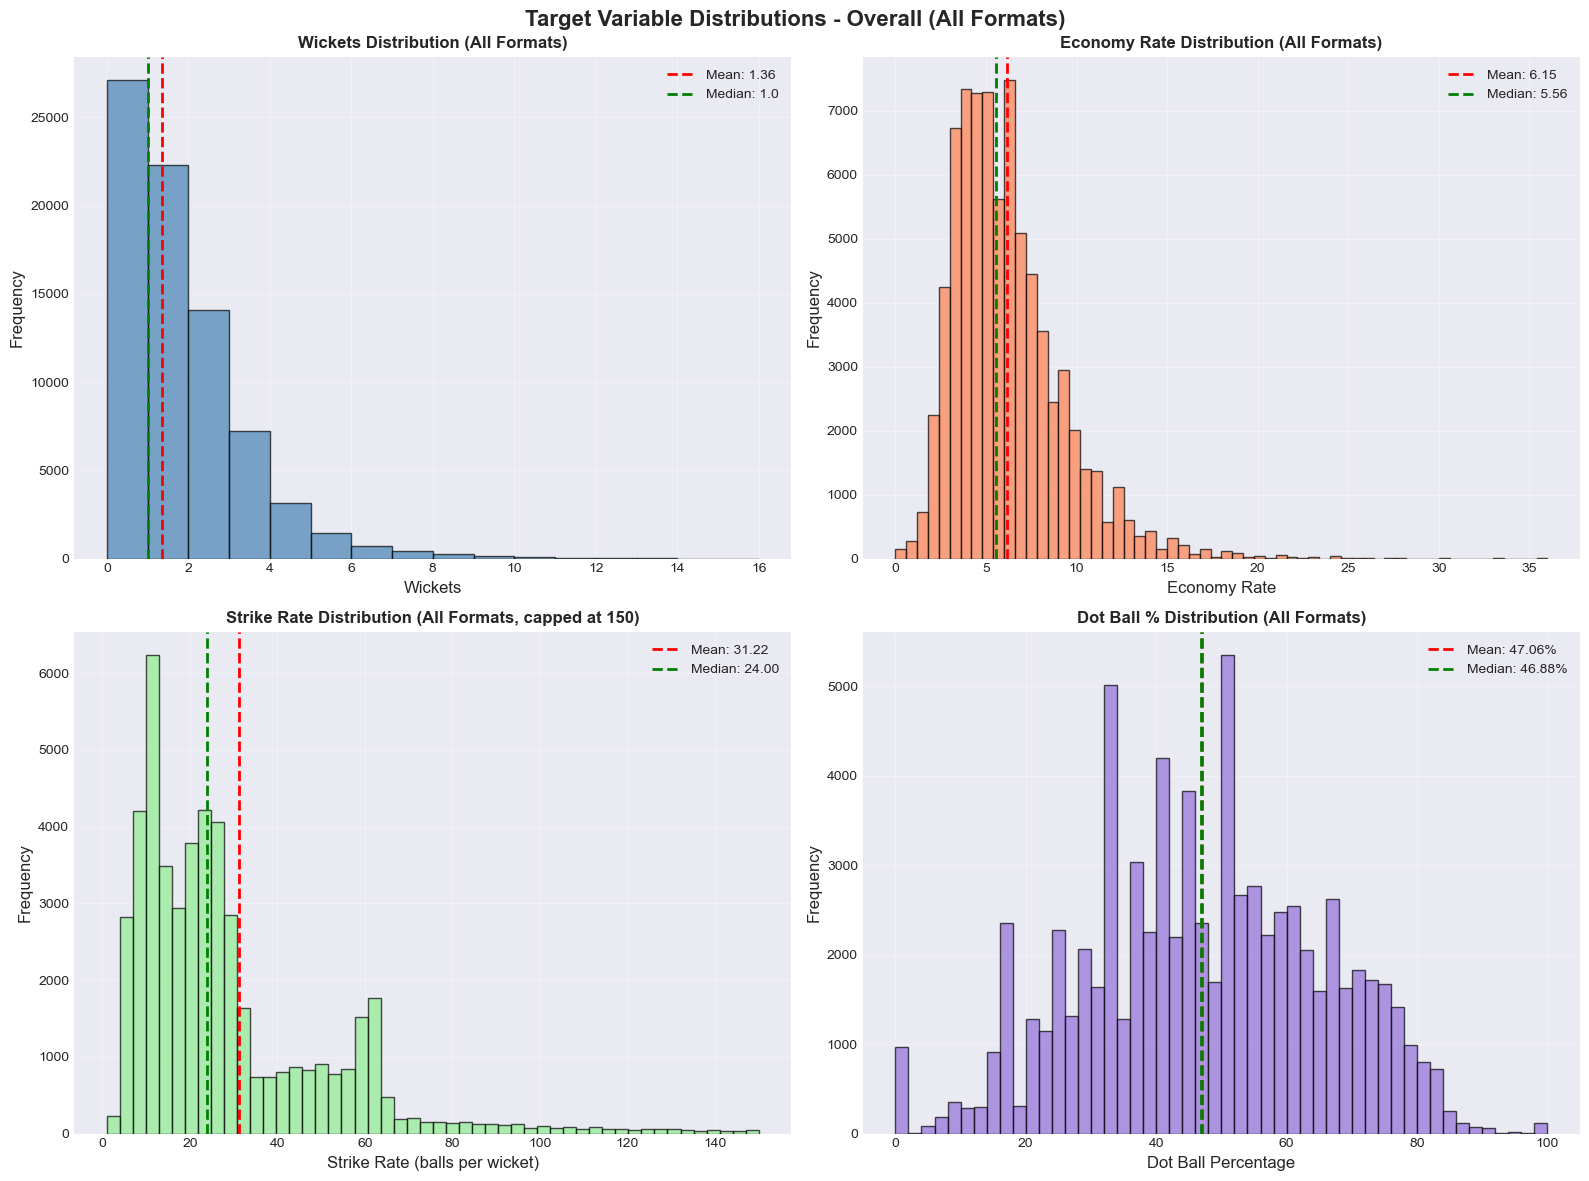



--------------------------------------------------------------------------------
1.6 FORMAT-SPECIFIC DISTRIBUTIONS
--------------------------------------------------------------------------------

✅ Saved: eda_phase1_format_distributions.png


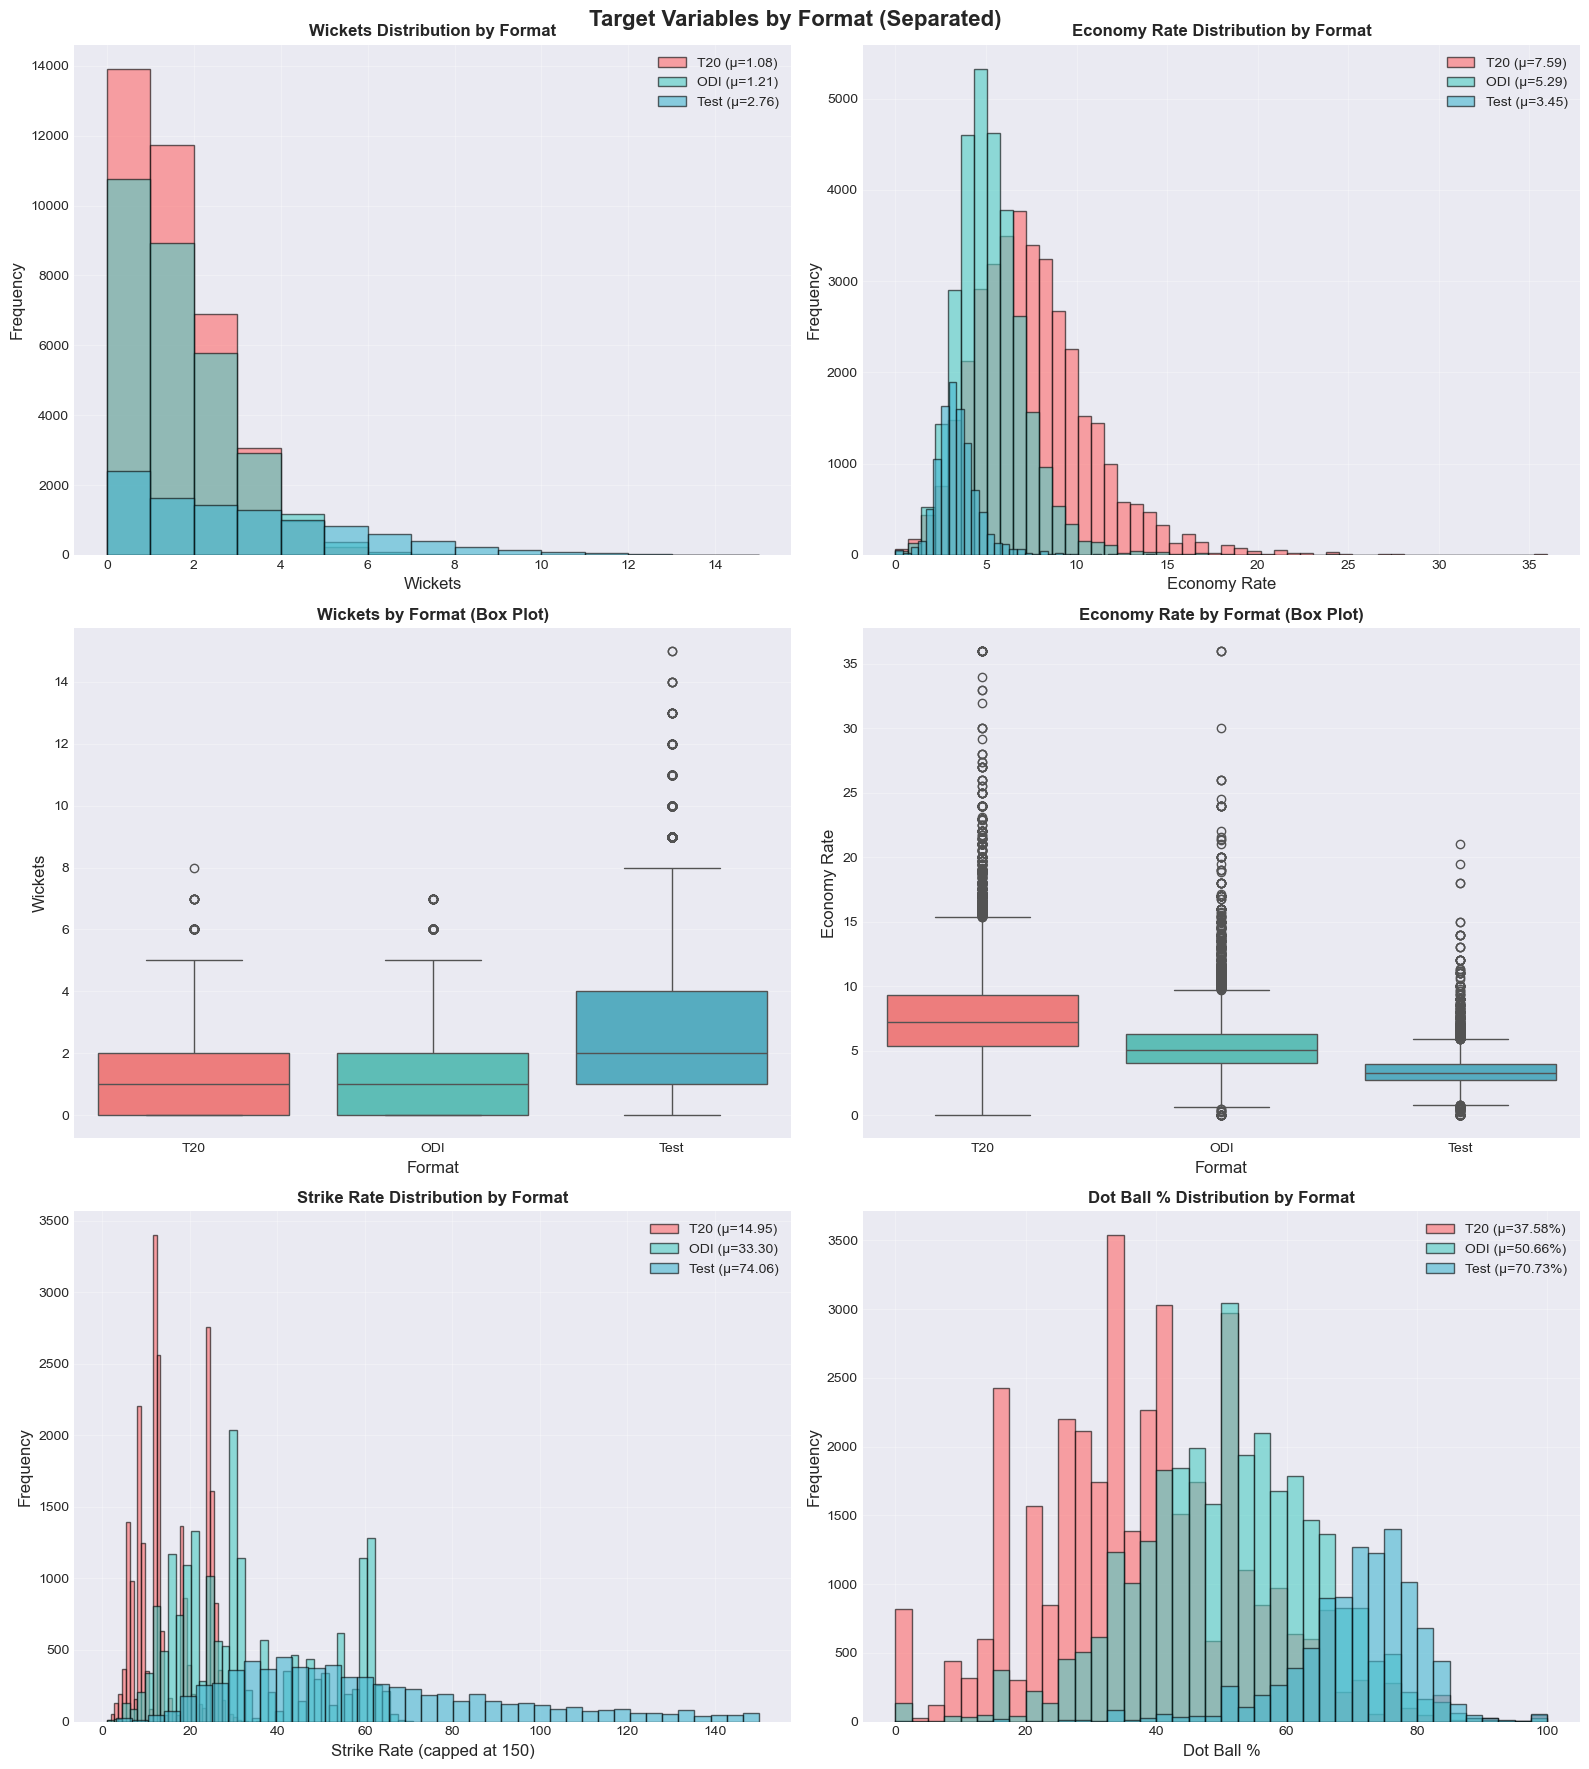



1.7 TEMPORAL TRENDS - ANALYZED BY FORMAT

📊 AVERAGE WICKETS PER MATCH TRENDS (2015-2025):
   T20: decreasing (-0.06 change)
   ODI: increasing (+0.12 change)
   Test: increasing (+0.15 change)

📊 AVERAGE ECONOMY RATE TRENDS (2015-2025):
   T20: increasing (+0.04 change)
   ODI: decreasing (-0.22 change)
   Test: increasing (+0.32 change)

✅ Saved: eda_phase1_temporal_trends_by_format.png


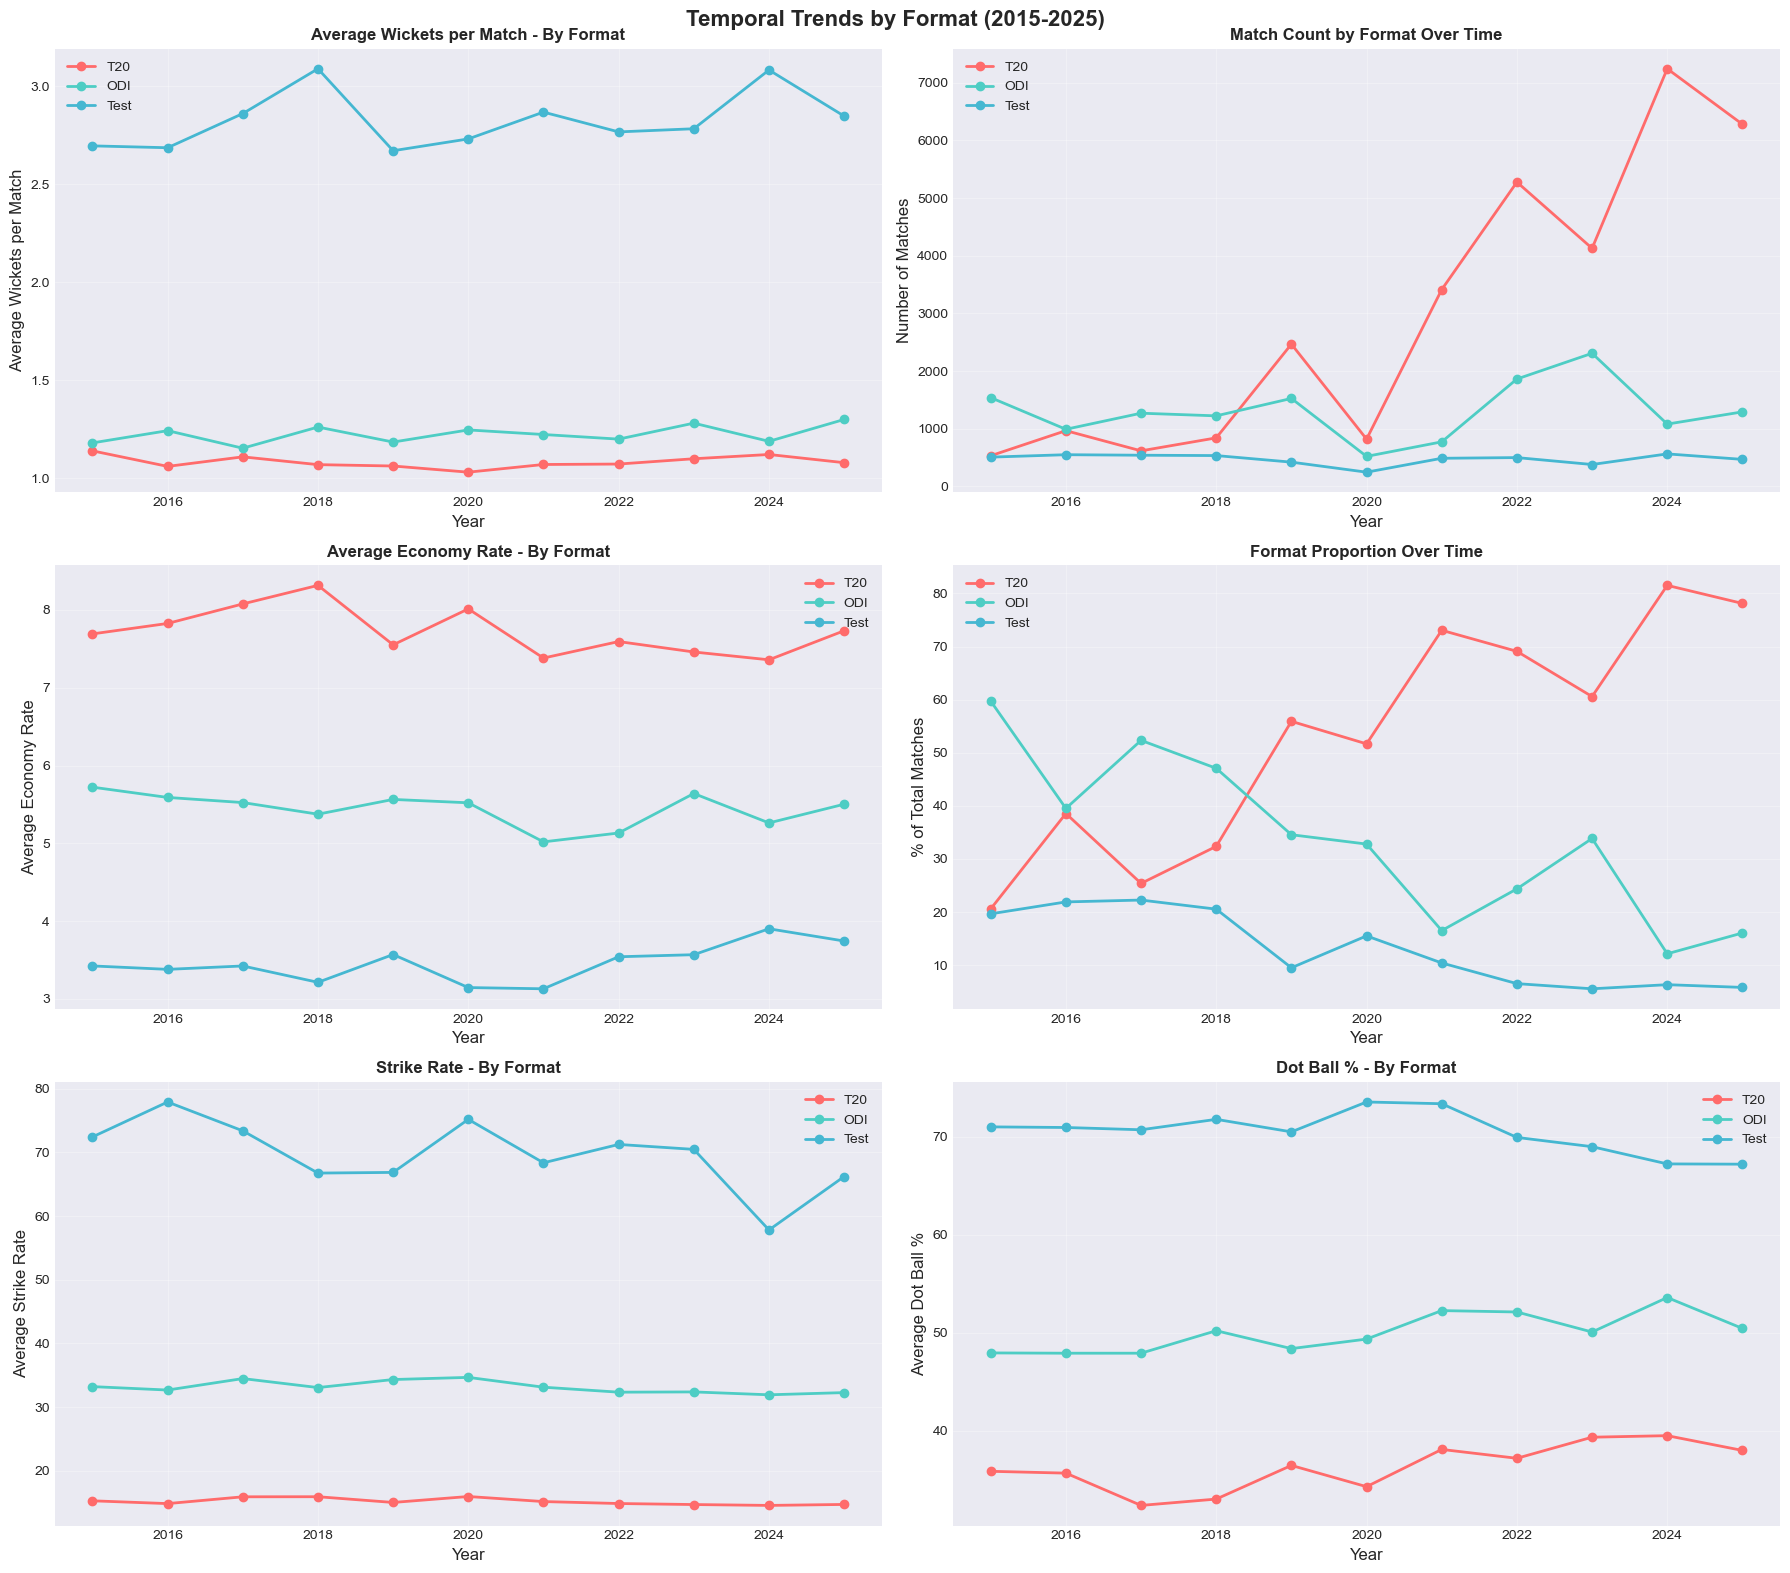



--------------------------------------------------------------------------------
1.8 TARGET CORRELATIONS
--------------------------------------------------------------------------------

📊 Overall correlation (all formats):
                     wickets  economy_rate  strike_rate  dot_ball_percentage
wickets                1.000        -0.340       -0.116                0.414
economy_rate          -0.340         1.000       -0.288               -0.769
strike_rate           -0.116        -0.288        1.000                0.353
dot_ball_percentage    0.414        -0.769        0.353                1.000

📊 T20 correlation:
                     wickets  economy_rate  strike_rate  dot_ball_percentage
wickets                1.000        -0.349       -0.721                0.376
economy_rate          -0.349         1.000        0.154               -0.685
strike_rate           -0.721         0.154        1.000               -0.245
dot_ball_percentage    0.376        -0.685       -0.245      

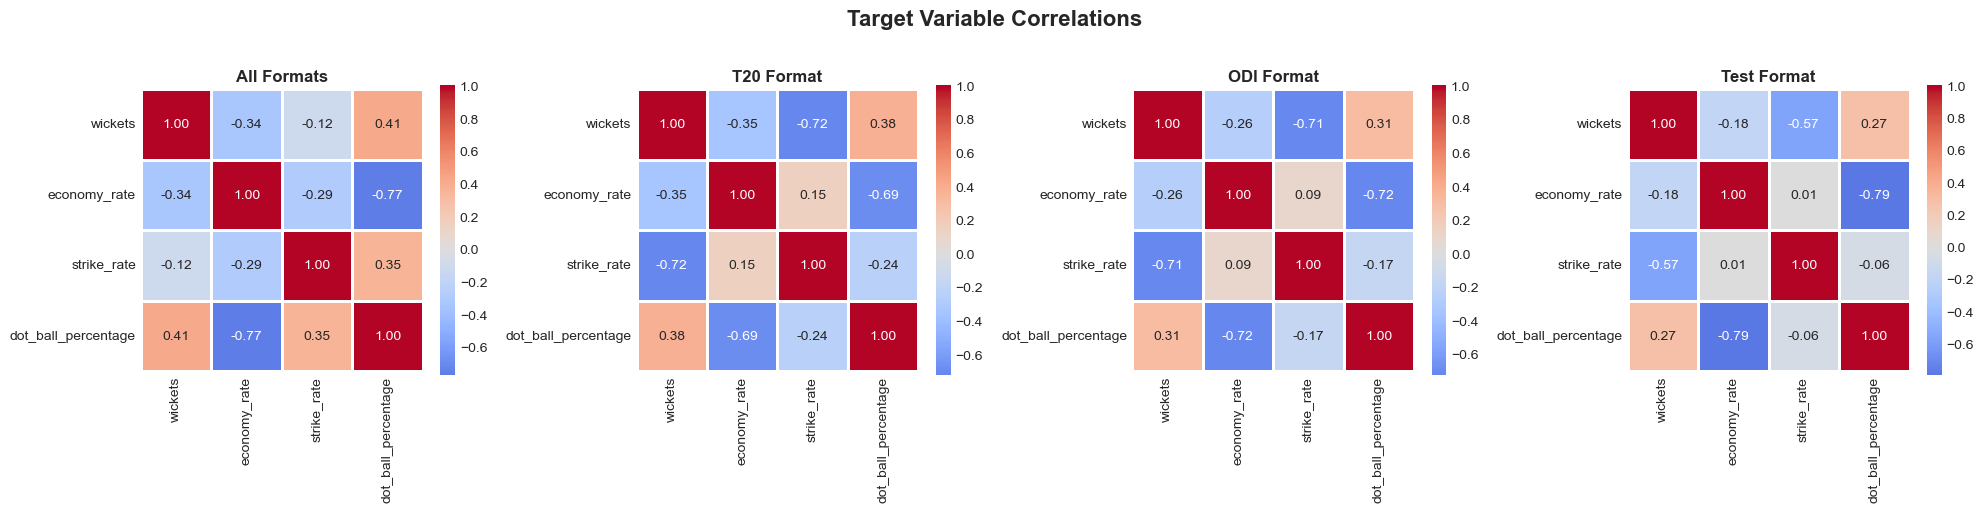



✅ EDA PHASE 1 COMPLETE: FORMAT-AWARE TARGET ANALYSIS

📊 KEY INSIGHTS:
--------------------------------------------------------------------------------

1. FORMAT DIFFERENCES (CRITICAL!):
   T20:  High economy (7.59), low wickets (1.08)
   ODI:  Medium economy (5.29), medium wickets (1.21)
   Test: Low economy (3.45), high wickets (2.76)
   → MUST build format-specific models!

2. TEMPORAL TRENDS:
   Format proportions changing over time
   Within-format trends are more meaningful than overall trends
   Recent years: more T20, affecting overall statistics

3. TARGET CHARACTERISTICS:
   Wickets: Highly skewed (35% get 0 wickets)
   Economy: Strong negative correlation with dot% (-0.77)
   Strike Rate: 35% missing (no wickets taken)
   → May need classification (0 vs 1+ wickets) + regression

4. MODELING IMPLICATIONS:
   ✓ Separate models per format essential
   ✓ Wickets: Consider classification (0/1/2/3+)
   ✓ Economy: Direct regression target
   ✓ Dot%: Alternative to economy (highly

In [2]:
"""
EDA PHASE 1 REVISED: TARGET VARIABLE ANALYSIS (FORMAT-AWARE)
=============================================================
Deep analysis of what we're trying to predict, with proper format separation
"""

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("\n" + "="*80)
print("📊 EDA PHASE 1: TARGET VARIABLE DEEP DIVE (FORMAT-AWARE)")
print("="*80)

# ============================================================================
# 1.1 OVERALL DATASET COMPOSITION
# ============================================================================
print("\n" + "-"*80)
print("1.1 DATASET COMPOSITION BY FORMAT")
print("-"*80)

format_breakdown = abt['match_type'].value_counts()
print(f"\n📊 Total matches: {len(abt):,}")
print(f"\nFormat breakdown:")
for format_type, count in format_breakdown.items():
    pct = count / len(abt) * 100
    print(f"   {format_type}: {count:,} ({pct:.1f}%)")

# Format distribution over time
format_by_year = abt.groupby(['match_year', 'match_type']).size().unstack(fill_value=0)
format_pct_by_year = format_by_year.div(format_by_year.sum(axis=1), axis=0) * 100

print(f"\n📊 Format composition in recent years (%):")
print(format_pct_by_year.tail(5).round(1).to_string())

print(f"\n💡 KEY INSIGHT:")
print(f"   T20 proportion has {'increased' if format_pct_by_year['T20'].iloc[-1] > format_pct_by_year['T20'].iloc[0] else 'decreased'} over time")
print(f"   This affects overall trends - need format-specific analysis!")

# ============================================================================
# 1.2 PRIMARY TARGETS - OVERALL OVERVIEW
# ============================================================================
print("\n\n" + "-"*80)
print("1.2 PRIMARY TARGET VARIABLES - OVERALL STATISTICS")
print("-"*80)

targets = {
    'wickets': 'Number of wickets taken',
    'economy_rate': 'Runs conceded per over',
    'strike_rate': 'Balls bowled per wicket',
    'dot_ball_percentage': 'Percentage of dot balls'
}

print("\n📊 Overall target characteristics (ALL FORMATS COMBINED):\n")

overall_stats = []
for target, description in targets.items():
    data = abt[target].dropna()
    
    stats_dict = {
        'Target': target,
        'Count': len(data),
        'Missing': abt[target].isna().sum(),
        'Missing%': round(abt[target].isna().sum()/len(abt)*100, 2),
        'Mean': round(data.mean(), 2),
        'Median': round(data.median(), 2),
        'Std': round(data.std(), 2),
        'Min': round(data.min(), 2),
        'Max': round(data.max(), 2),
        'Skewness': round(data.skew(), 2)
    }
    overall_stats.append(stats_dict)

overall_df = pd.DataFrame(overall_stats)
print(overall_df.to_string(index=False))

# ============================================================================
# 1.3 WICKETS DISTRIBUTION - OVERALL
# ============================================================================
print("\n\n" + "-"*80)
print("1.3 WICKETS DISTRIBUTION - OVERALL")
print("-"*80)

wickets = abt['wickets'].dropna()

print(f"\n📊 Wickets frequency (ALL FORMATS):")
wickets_counts = wickets.value_counts().sort_index()
for w, count in wickets_counts.items():
    pct = count / len(wickets) * 100
    print(f"   {int(w)} wickets: {count:,} ({pct:.2f}%)")

print(f"\n📊 Wickets buckets:")
print(f"   0 wickets: {(wickets == 0).sum():,} ({(wickets == 0).sum()/len(wickets)*100:.1f}%)")
print(f"   1-2 wickets: {((wickets >= 1) & (wickets <= 2)).sum():,} ({((wickets >= 1) & (wickets <= 2)).sum()/len(wickets)*100:.1f}%)")
print(f"   3-4 wickets: {((wickets >= 3) & (wickets <= 4)).sum():,} ({((wickets >= 3) & (wickets <= 4)).sum()/len(wickets)*100:.1f}%)")
print(f"   5+ wickets: {(wickets >= 5).sum():,} ({(wickets >= 5).sum()/len(wickets)*100:.1f}%)")

# ============================================================================
# 1.4 FORMAT-SPECIFIC TARGET STATISTICS
# ============================================================================
print("\n\n" + "="*80)
print("1.4 FORMAT-SPECIFIC TARGET STATISTICS")
print("="*80)

format_stats = []
for format_type in ['T20', 'ODI', 'Test']:
    format_data = abt[abt['match_type'] == format_type]
    
    print(f"\n{'-'*80}")
    print(f"{format_type} FORMAT")
    print(f"{'-'*80}")
    print(f"   Matches: {len(format_data):,}")
    
    for target in targets.keys():
        data = format_data[target].dropna()
        if len(data) > 0:
            print(f"\n   {target}:")
            print(f"      Count: {len(data):,}")
            print(f"      Mean: {data.mean():.2f}")
            print(f"      Median: {data.median():.2f}")
            print(f"      Std: {data.std():.2f}")
            print(f"      Min-Max: [{data.min():.2f}, {data.max():.2f}]")
            
            # Store for comparison
            format_stats.append({
                'Format': format_type,
                'Target': target,
                'Mean': round(data.mean(), 2),
                'Median': round(data.median(), 2),
                'Std': round(data.std(), 2)
            })

# Format comparison table
print(f"\n\n📊 FORMAT COMPARISON TABLE:")
print(f"{'='*80}")
format_comparison = pd.DataFrame(format_stats)
for target in targets.keys():
    target_comp = format_comparison[format_comparison['Target'] == target]
    print(f"\n{target.upper()}:")
    print(target_comp[['Format', 'Mean', 'Median', 'Std']].to_string(index=False))

# ============================================================================
# 1.5 VISUALIZATIONS - OVERALL DISTRIBUTIONS
# ============================================================================
print("\n\n" + "-"*80)
print("1.5 CREATING OVERALL DISTRIBUTION VISUALIZATIONS")
print("-"*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Target Variable Distributions - Overall (All Formats)', 
             fontsize=16, fontweight='bold')

# 1. Wickets
ax = axes[0, 0]
wickets_data = abt['wickets'].dropna()
ax.hist(wickets_data, bins=range(0, int(wickets_data.max())+2), 
        edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(wickets_data.mean(), color='red', linestyle='--', linewidth=2, 
           label=f'Mean: {wickets_data.mean():.2f}')
ax.axvline(wickets_data.median(), color='green', linestyle='--', linewidth=2,
           label=f'Median: {wickets_data.median():.1f}')
ax.set_xlabel('Wickets', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Wickets Distribution (All Formats)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Economy Rate
ax = axes[0, 1]
economy_data = abt['economy_rate'].dropna()
ax.hist(economy_data, bins=60, edgecolor='black', alpha=0.7, color='coral')
ax.axvline(economy_data.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {economy_data.mean():.2f}')
ax.axvline(economy_data.median(), color='green', linestyle='--', linewidth=2,
           label=f'Median: {economy_data.median():.2f}')
ax.set_xlabel('Economy Rate', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Economy Rate Distribution (All Formats)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Strike Rate
ax = axes[1, 0]
sr_data = abt['strike_rate'].dropna()
# Filter extreme outliers for better visualization
sr_display = sr_data[sr_data <= 150]
ax.hist(sr_display, bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
ax.axvline(sr_data.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {sr_data.mean():.2f}')
ax.axvline(sr_data.median(), color='green', linestyle='--', linewidth=2,
           label=f'Median: {sr_data.median():.2f}')
ax.set_xlabel('Strike Rate (balls per wicket)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Strike Rate Distribution (All Formats, capped at 150)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Dot Ball %
ax = axes[1, 1]
dot_data = abt['dot_ball_percentage'].dropna()
ax.hist(dot_data, bins=50, edgecolor='black', alpha=0.7, color='mediumpurple')
ax.axvline(dot_data.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {dot_data.mean():.2f}%')
ax.axvline(dot_data.median(), color='green', linestyle='--', linewidth=2,
           label=f'Median: {dot_data.median():.2f}%')
ax.set_xlabel('Dot Ball Percentage', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Dot Ball % Distribution (All Formats)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_phase1_overall_distributions.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: eda_phase1_overall_distributions.png")
plt.show()

# ============================================================================
# 1.6 FORMAT-SPECIFIC DISTRIBUTIONS (SIDE-BY-SIDE)
# ============================================================================
print("\n\n" + "-"*80)
print("1.6 FORMAT-SPECIFIC DISTRIBUTIONS")
print("-"*80)

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Target Variables by Format (Separated)', fontsize=16, fontweight='bold')

formats = ['T20', 'ODI', 'Test']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# Wickets by format
ax = axes[0, 0]
for i, fmt in enumerate(formats):
    fmt_data = abt[abt['match_type'] == fmt]['wickets'].dropna()
    ax.hist(fmt_data, bins=range(0, 16), alpha=0.6, label=f'{fmt} (μ={fmt_data.mean():.2f})',
            color=colors[i], edgecolor='black')
ax.set_xlabel('Wickets', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Wickets Distribution by Format', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Economy by format
ax = axes[0, 1]
for i, fmt in enumerate(formats):
    fmt_data = abt[abt['match_type'] == fmt]['economy_rate'].dropna()
    ax.hist(fmt_data, bins=50, alpha=0.6, label=f'{fmt} (μ={fmt_data.mean():.2f})',
            color=colors[i], edgecolor='black')
ax.set_xlabel('Economy Rate', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Economy Rate Distribution by Format', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Wickets - Box plots
ax = axes[1, 0]
abt_plot = abt[abt['match_type'].isin(formats)]
sns.boxplot(data=abt_plot, x='match_type', y='wickets', ax=ax, 
            palette=colors, order=formats)
ax.set_xlabel('Format', fontsize=12)
ax.set_ylabel('Wickets', fontsize=12)
ax.set_title('Wickets by Format (Box Plot)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Economy - Box plots
ax = axes[1, 1]
sns.boxplot(data=abt_plot, x='match_type', y='economy_rate', ax=ax,
            palette=colors, order=formats)
ax.set_xlabel('Format', fontsize=12)
ax.set_ylabel('Economy Rate', fontsize=12)
ax.set_title('Economy Rate by Format (Box Plot)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Strike Rate by format
ax = axes[2, 0]
for i, fmt in enumerate(formats):
    fmt_data = abt[abt['match_type'] == fmt]['strike_rate'].dropna()
    fmt_data_display = fmt_data[fmt_data <= 150]  # Cap for visualization
    ax.hist(fmt_data_display, bins=40, alpha=0.6, label=f'{fmt} (μ={fmt_data.mean():.2f})',
            color=colors[i], edgecolor='black')
ax.set_xlabel('Strike Rate (capped at 150)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Strike Rate Distribution by Format', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Dot Ball % by format
ax = axes[2, 1]
for i, fmt in enumerate(formats):
    fmt_data = abt[abt['match_type'] == fmt]['dot_ball_percentage'].dropna()
    ax.hist(fmt_data, bins=40, alpha=0.6, label=f'{fmt} (μ={fmt_data.mean():.2f}%)',
            color=colors[i], edgecolor='black')
ax.set_xlabel('Dot Ball %', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Dot Ball % Distribution by Format', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_phase1_format_distributions.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: eda_phase1_format_distributions.png")
plt.show()

# ============================================================================
# 1.7 TEMPORAL TRENDS - FORMAT-SPECIFIC (CRITICAL!)
# ============================================================================
print("\n\n" + "="*80)
print("1.7 TEMPORAL TRENDS - ANALYZED BY FORMAT")
print("="*80)

fig, axes = plt.subplots(3, 2, figsize=(18, 16))
fig.suptitle('Temporal Trends by Format (2015-2025)', fontsize=16, fontweight='bold')

# Filter to last 10 years for clearer trends
recent_abt = abt[abt['match_year'] >= 2015]

target_pairs = [
    ('wickets', 'Average Wickets per Match'),
    ('economy_rate', 'Average Economy Rate'),
    ('strike_rate', 'Average Strike Rate'),
    ('dot_ball_percentage', 'Average Dot Ball %'),
]

for idx, (target, title) in enumerate(target_pairs[:2]):
    ax = axes[idx, 0]
    
    for i, fmt in enumerate(formats):
        fmt_yearly = recent_abt[recent_abt['match_type'] == fmt].groupby('match_year')[target].mean()
        ax.plot(fmt_yearly.index, fmt_yearly.values, marker='o', linewidth=2, 
                label=fmt, color=colors[i])
    
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel(title, fontsize=12)
    ax.set_title(f'{title} - By Format', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Print trend analysis
    print(f"\n📊 {title.upper()} TRENDS (2015-2025):")
    for fmt in formats:
        fmt_yearly = recent_abt[recent_abt['match_type'] == fmt].groupby('match_year')[target].mean()
        if len(fmt_yearly) >= 2:
            trend = "increasing" if fmt_yearly.iloc[-1] > fmt_yearly.iloc[0] else "decreasing"
            change = fmt_yearly.iloc[-1] - fmt_yearly.iloc[0]
            print(f"   {fmt}: {trend} ({change:+.2f} change)")

# Match counts by format over time
ax = axes[0, 1]
format_yearly_counts = recent_abt.groupby(['match_year', 'match_type']).size().unstack(fill_value=0)
for i, fmt in enumerate(formats):
    if fmt in format_yearly_counts.columns:
        ax.plot(format_yearly_counts.index, format_yearly_counts[fmt], 
                marker='o', linewidth=2, label=fmt, color=colors[i])
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Matches', fontsize=12)
ax.set_title('Match Count by Format Over Time', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Format proportion over time
ax = axes[1, 1]
format_pct_yearly = format_yearly_counts.div(format_yearly_counts.sum(axis=1), axis=0) * 100
for i, fmt in enumerate(formats):
    if fmt in format_pct_yearly.columns:
        ax.plot(format_pct_yearly.index, format_pct_yearly[fmt],
                marker='o', linewidth=2, label=fmt, color=colors[i])
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('% of Total Matches', fontsize=12)
ax.set_title('Format Proportion Over Time', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Strike rate trends
ax = axes[2, 0]
for i, fmt in enumerate(formats):
    fmt_yearly = recent_abt[recent_abt['match_type'] == fmt].groupby('match_year')['strike_rate'].mean()
    ax.plot(fmt_yearly.index, fmt_yearly.values, marker='o', linewidth=2,
            label=fmt, color=colors[i])
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Average Strike Rate', fontsize=12)
ax.set_title('Strike Rate - By Format', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Dot ball % trends
ax = axes[2, 1]
for i, fmt in enumerate(formats):
    fmt_yearly = recent_abt[recent_abt['match_type'] == fmt].groupby('match_year')['dot_ball_percentage'].mean()
    ax.plot(fmt_yearly.index, fmt_yearly.values, marker='o', linewidth=2,
            label=fmt, color=colors[i])
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Average Dot Ball %', fontsize=12)
ax.set_title('Dot Ball % - By Format', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_phase1_temporal_trends_by_format.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: eda_phase1_temporal_trends_by_format.png")
plt.show()

# ============================================================================
# 1.8 CORRELATION - OVERALL vs BY FORMAT
# ============================================================================
print("\n\n" + "-"*80)
print("1.8 TARGET CORRELATIONS")
print("-"*80)

target_cols = ['wickets', 'economy_rate', 'strike_rate', 'dot_ball_percentage']

# Overall correlation
print(f"\n📊 Overall correlation (all formats):")
overall_corr = abt[target_cols].corr()
print(overall_corr.round(3).to_string())

# Format-specific correlations
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Target Variable Correlations', fontsize=16, fontweight='bold')

# Overall
ax = axes[0]
sns.heatmap(overall_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('All Formats', fontsize=12, fontweight='bold')

# By format
for i, fmt in enumerate(formats):
    ax = axes[i+1]
    fmt_data = abt[abt['match_type'] == fmt][target_cols]
    fmt_corr = fmt_data.corr()
    
    sns.heatmap(fmt_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
    ax.set_title(f'{fmt} Format', fontsize=12, fontweight='bold')
    
    print(f"\n📊 {fmt} correlation:")
    print(fmt_corr.round(3).to_string())

plt.tight_layout()
plt.savefig('eda_phase1_correlations.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: eda_phase1_correlations.png")
plt.show()

# ============================================================================
# PHASE 1 SUMMARY
# ============================================================================
print("\n\n" + "="*80)
print("✅ EDA PHASE 1 COMPLETE: FORMAT-AWARE TARGET ANALYSIS")
print("="*80)

print("\n📊 KEY INSIGHTS:")
print("-"*80)

print("\n1. FORMAT DIFFERENCES (CRITICAL!):")
print(f"   T20:  High economy ({abt[abt['match_type']=='T20']['economy_rate'].mean():.2f}), low wickets ({abt[abt['match_type']=='T20']['wickets'].mean():.2f})")
print(f"   ODI:  Medium economy ({abt[abt['match_type']=='ODI']['economy_rate'].mean():.2f}), medium wickets ({abt[abt['match_type']=='ODI']['wickets'].mean():.2f})")
print(f"   Test: Low economy ({abt[abt['match_type']=='Test']['economy_rate'].mean():.2f}), high wickets ({abt[abt['match_type']=='Test']['wickets'].mean():.2f})")
print(f"   → MUST build format-specific models!")

print("\n2. TEMPORAL TRENDS:")
print(f"   Format proportions changing over time")
print(f"   Within-format trends are more meaningful than overall trends")
print(f"   Recent years: more T20, affecting overall statistics")

print("\n3. TARGET CHARACTERISTICS:")
print(f"   Wickets: Highly skewed (35% get 0 wickets)")
print(f"   Economy: Strong negative correlation with dot% (-0.77)")
print(f"   Strike Rate: 35% missing (no wickets taken)")
print(f"   → May need classification (0 vs 1+ wickets) + regression")

print("\n4. MODELING IMPLICATIONS:")
print(f"   ✓ Separate models per format essential")
print(f"   ✓ Wickets: Consider classification (0/1/2/3+)")
print(f"   ✓ Economy: Direct regression target")
print(f"   ✓ Dot%: Alternative to economy (highly correlated)")

print("\n📁 FILES CREATED:")
print("   - eda_phase1_overall_distributions.png")
print("   - eda_phase1_format_distributions.png")
print("   - eda_phase1_temporal_trends_by_format.png")
print("   - eda_phase1_correlations.png")

print("\n🚀 READY FOR PHASE 2: FEATURE ANALYSIS")
print("="*80)


📊 EDA PHASE 2: FEATURE ANALYSIS

📊 Loading ABT...
✅ Loaded: 77,031 rows, 161 columns

--------------------------------------------------------------------------------
2.1 FEATURE CATEGORIES IN ABT
--------------------------------------------------------------------------------

📊 Feature groups summary:
   Career Aggregates: 18 features
   Rolling Windows (Form): 15 features
   Venue Features: 9 features
   Opponent Features: 10 features
   Context Features: 9 features

   Total engineered features: 61
   Total columns in ABT: 161


--------------------------------------------------------------------------------
2.2 MISSING VALUE PATTERNS IN FEATURES
--------------------------------------------------------------------------------

📊 Features with >10% missing values:
                 Feature  Missing_Count  Missing_Pct
     economy_last_5_test          67626        87.79
     career_economy_test          67626        87.79
      economy_last_5_odi          48452        62.90
      car

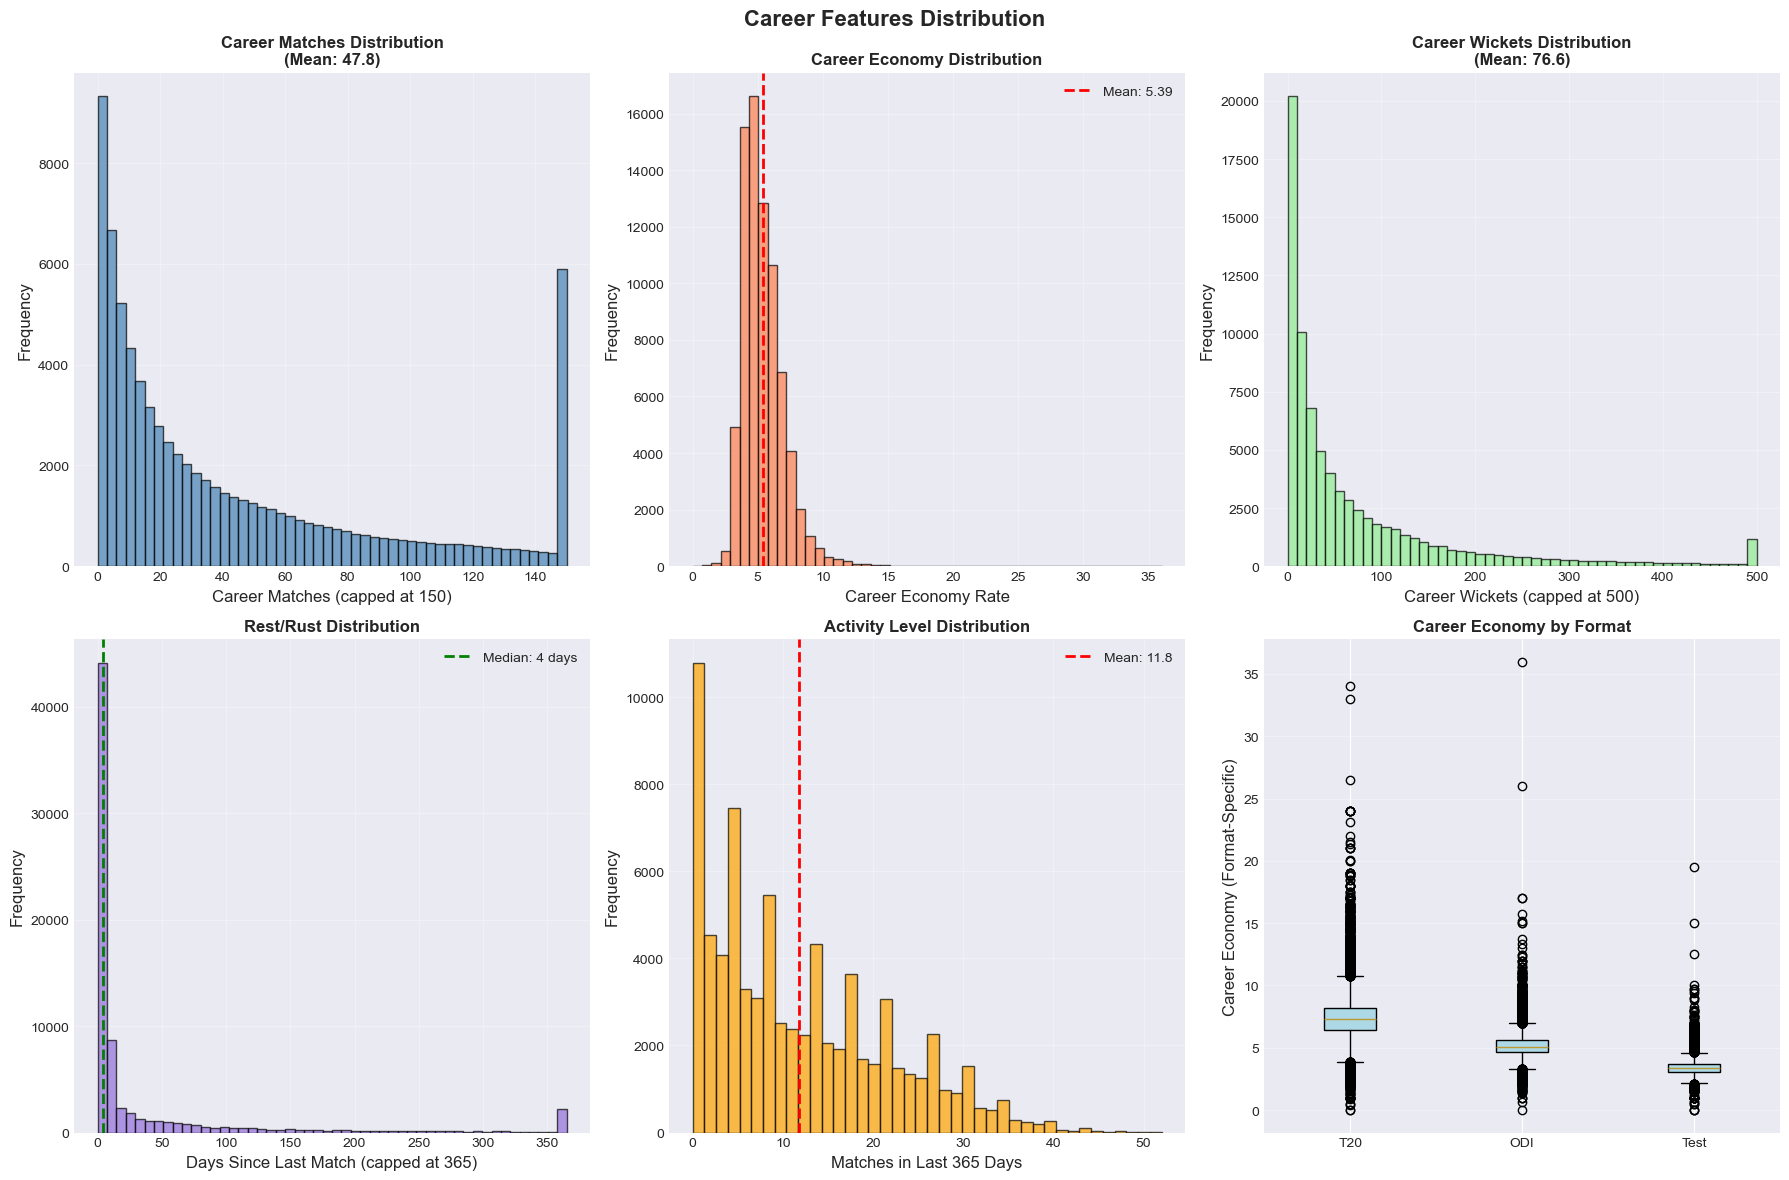



--------------------------------------------------------------------------------
2.4 CAREER FEATURES vs TARGET VARIABLES
--------------------------------------------------------------------------------

📊 Correlation: Career Features vs Targets

WICKETS:
   career_dot_ball_pct: +0.230
   career_economy: -0.197
   career_wickets_total: +0.179
   career_strike_rate: +0.116
   career_matches: +0.100

ECONOMY_RATE:
   career_economy: +0.332
   career_dot_ball_pct: -0.312
   career_strike_rate: -0.213
   career_wickets_total: -0.128
   matches_last_365_days: -0.094

STRIKE_RATE:
   career_dot_ball_pct: +0.333
   career_economy: -0.333
   career_strike_rate: +0.289
   career_wickets_total: +0.172
   career_matches: +0.125

DOT_BALL_PERCENTAGE:
   career_dot_ball_pct: +0.415
   career_economy: -0.362
   career_strike_rate: +0.228
   career_wickets_total: +0.181
   career_matches: +0.113

✅ Saved: eda_phase2_career_vs_targets.png


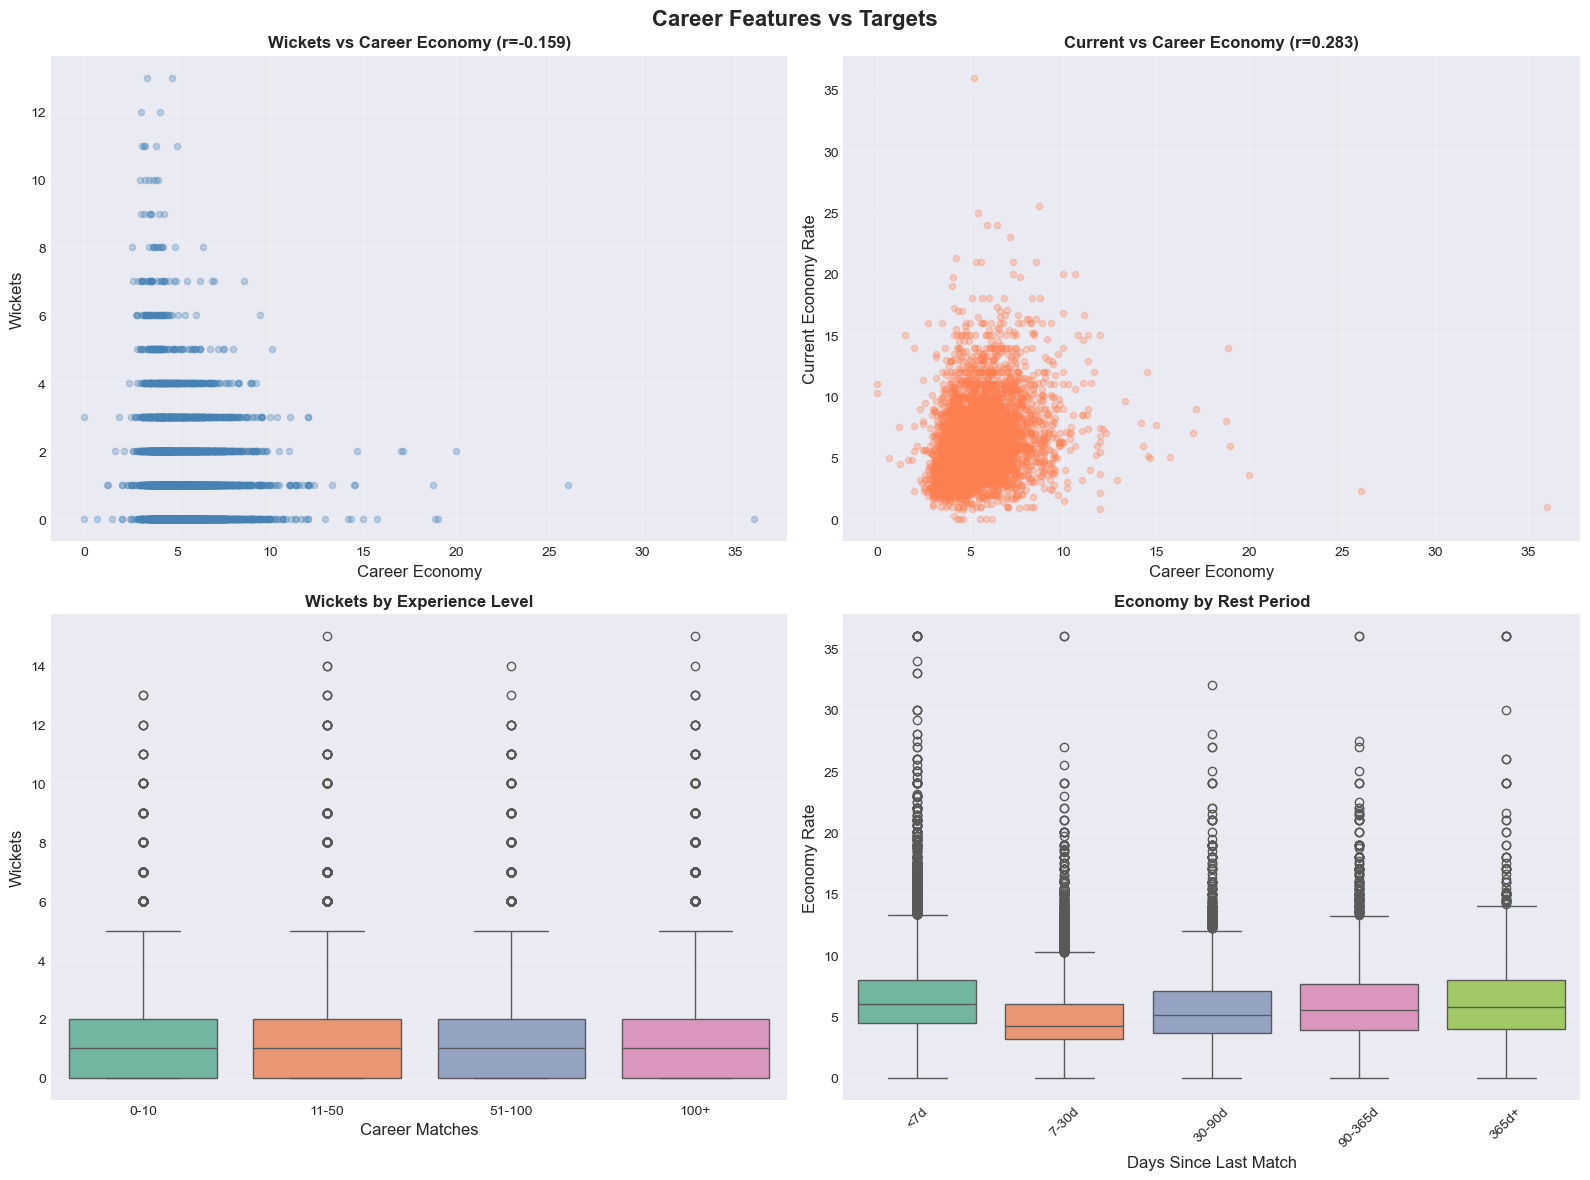



2.5 ROLLING WINDOW FEATURES (RECENT FORM)

📊 Form features available: 15

📊 Recent form statistics:

LAST 5 MATCHES:
   wickets_last_5: Mean=6.39, Median=6.00, Available=77,031
   economy_last_5: Mean=6.10, Median=5.87, Available=77,030

LAST 10 MATCHES:
   wickets_last_10: Mean=11.94, Median=11.00, Available=77,031
   economy_last_10: Mean=6.08, Median=5.91, Available=77,030

📊 Form indicators:
   Improving economy: 38,102 (49.5%)
   On wicket streak: 26,829 (34.8%)
   Max streak: 34 consecutive matches

✅ Saved: eda_phase2_form_features.png


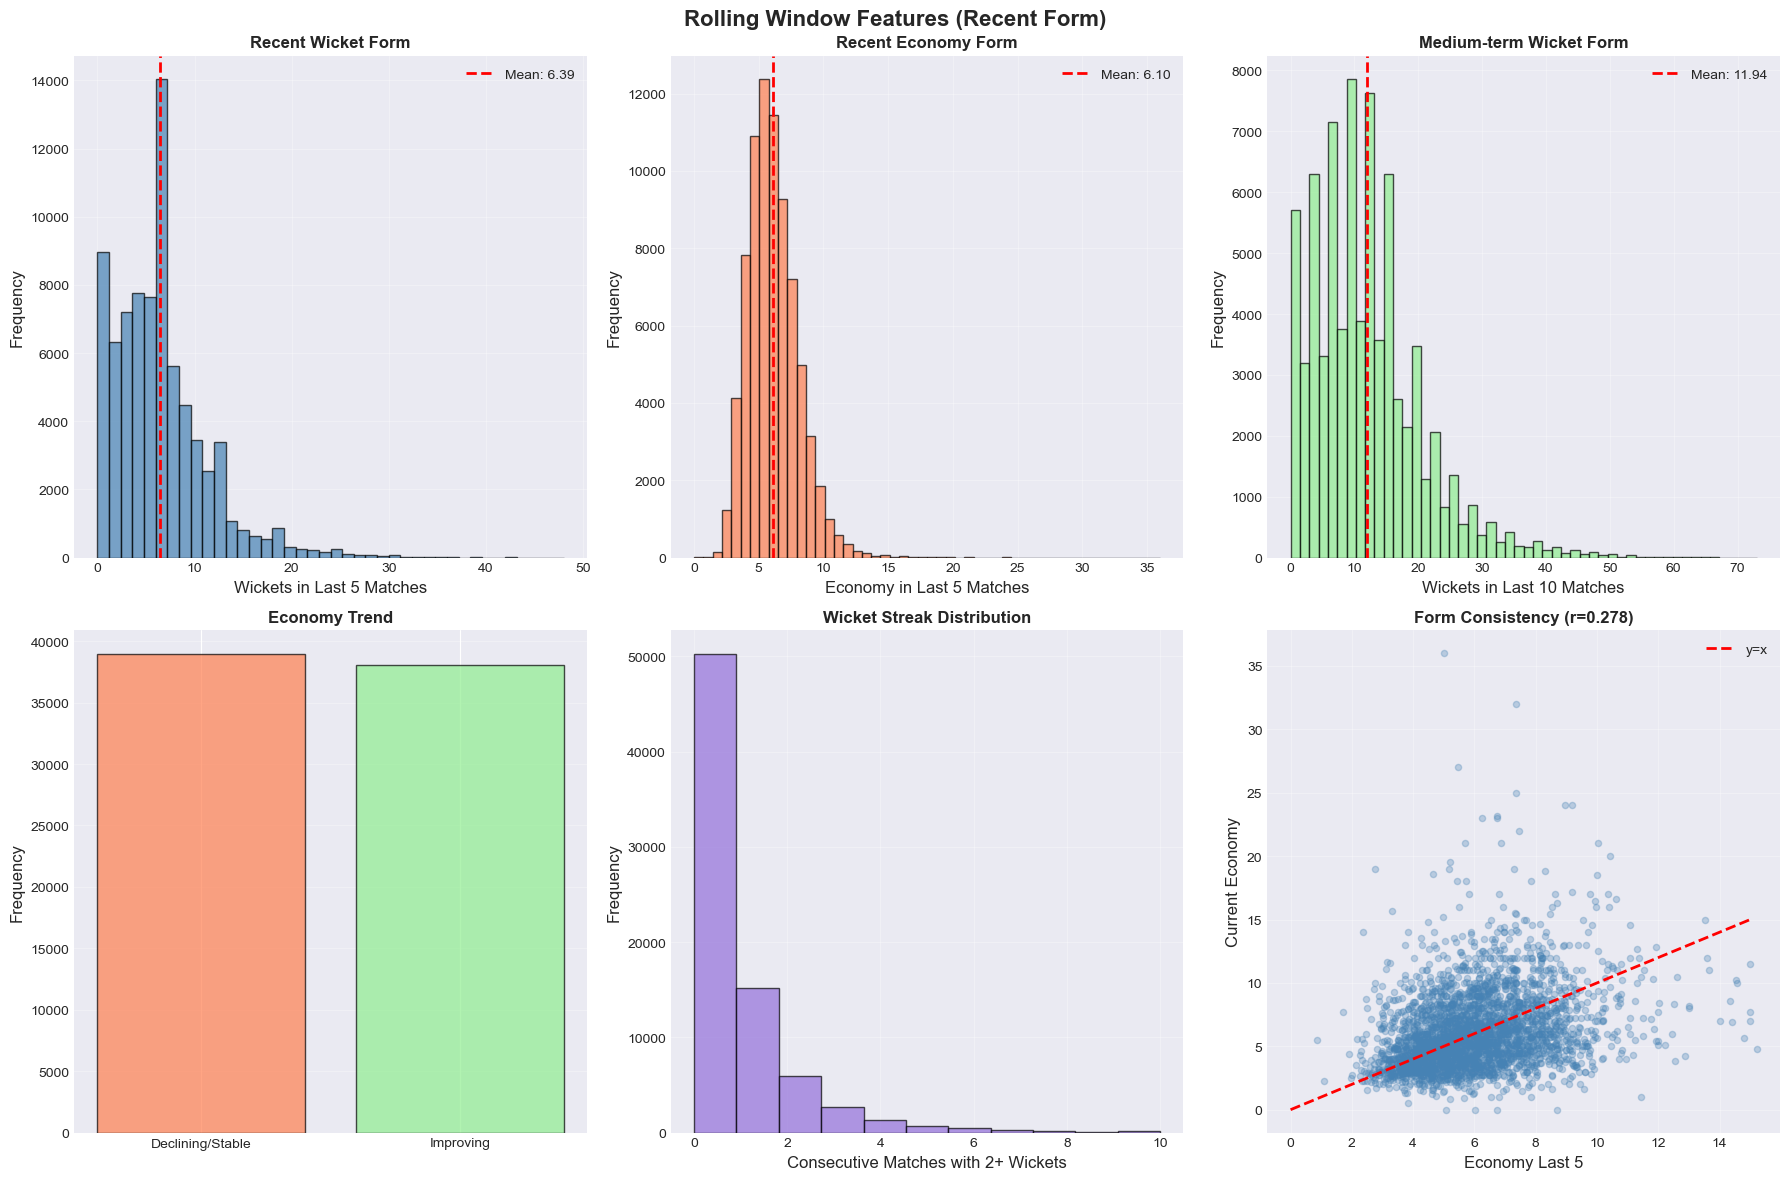



✅ EDA PHASE 2 - SECTIONS 1-2 COMPLETE

📊 KEY FINDINGS:
--------------------------------------------------------------------------------

1. CAREER FEATURES:
   ✓ career_economy: r=+0.33 with current economy
   ✓ career_dot_ball_pct: +0.42 with current dot%
   ✓ Veterans (100+ matches): 11,715 instances

2. FORM FEATURES:
   ✓ economy_last_5: r=0.278 with current
   ✓ Hot streaks: 3,134 on 3+ match streak

📁 FILES CREATED:
   - eda_phase2_career_features.png
   - eda_phase2_career_vs_targets.png
   - eda_phase2_form_features.png

🚀 READY FOR SECTION 3: Venue & Opponent Features


In [4]:
"""
EDA PHASE 2: FEATURE ANALYSIS (COMPLETE - STANDALONE)
======================================================
Run this in your new EDA Python file
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set styles
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("\n" + "="*80)
print("📊 EDA PHASE 2: FEATURE ANALYSIS")
print("="*80)

# ============================================================================
# 0. LOAD ABT
# ============================================================================
print("\n📊 Loading ABT...")
abt = pd.read_parquet('abt_final_with_all_features.parquet')
print(f"✅ Loaded: {len(abt):,} rows, {len(abt.columns)} columns")

# ============================================================================
# 1. DEFINE FEATURE GROUPS
# ============================================================================
feature_groups = {
    'Career Aggregates': [
        'career_matches', 'career_wickets_total', 'career_economy', 
        'career_strike_rate', 'career_bowling_average', 'career_dot_ball_pct',
        'career_matches_t20', 'career_economy_t20', 'career_wickets_t20',
        'career_matches_odi', 'career_economy_odi', 'career_wickets_odi',
        'career_matches_test', 'career_economy_test', 'career_wickets_test',
        'days_since_last_match', 'matches_last_365_days', 'is_debut'
    ],
    'Rolling Windows (Form)': [
        'wickets_last_5', 'economy_last_5', 'strike_rate_last_5', 'dot_pct_last_5',
        'wickets_last_10', 'economy_last_10', 'strike_rate_last_10',
        'wickets_last_5_t20', 'economy_last_5_t20',
        'wickets_last_5_odi', 'economy_last_5_odi',
        'wickets_last_5_test', 'economy_last_5_test',
        'economy_improving', 'wicket_streak'
    ],
    'Venue Features': [
        'matches_at_venue', 'economy_at_venue', 'wickets_at_venue',
        'strike_rate_at_venue', 'economy_in_country', 'wickets_in_country',
        'first_time_at_venue', 'venue_specialist', 'economy_vs_venue_avg'
    ],
    'Opponent Features': [
        'matches_vs_opponent', 'economy_vs_opponent', 'wickets_vs_opponent',
        'strike_rate_vs_opponent', 'opponent_batting_strength',
        'opponent_is_full_member', 'opponent_is_top8',
        'first_time_vs_opponent', 'opponent_specialist', 'economy_vs_opponent_diff'
    ],
    'Context Features': [
        'match_type', 'venue_country', 'venue_altitude', 'is_home_match',
        'bowler_bowling_style', 'bowler_age_at_match',
        'opponent_team_member_type', 'toss_decision', 'bowling_team_won_toss'
    ]
}

# ============================================================================
# 2.1 FEATURE CATEGORIES OVERVIEW
# ============================================================================
print("\n" + "-"*80)
print("2.1 FEATURE CATEGORIES IN ABT")
print("-"*80)

print(f"\n📊 Feature groups summary:")
total_engineered = 0
for group, features in feature_groups.items():
    available = [f for f in features if f in abt.columns]
    total_engineered += len(available)
    print(f"   {group}: {len(available)} features")

print(f"\n   Total engineered features: {total_engineered}")
print(f"   Total columns in ABT: {len(abt.columns)}")

# ============================================================================
# 2.2 MISSING VALUE PATTERNS
# ============================================================================
print("\n\n" + "-"*80)
print("2.2 MISSING VALUE PATTERNS IN FEATURES")
print("-"*80)

all_features = []
for features in feature_groups.values():
    all_features.extend([f for f in features if f in abt.columns])

missing_analysis = pd.DataFrame({
    'Feature': all_features,
    'Missing_Count': [abt[f].isna().sum() for f in all_features],
    'Missing_Pct': [(abt[f].isna().sum() / len(abt) * 100).round(2) for f in all_features]
})

missing_analysis = missing_analysis.sort_values('Missing_Pct', ascending=False)

print(f"\n📊 Features with >10% missing values:")
high_missing = missing_analysis[missing_analysis['Missing_Pct'] > 10]
if len(high_missing) > 0:
    print(high_missing.head(15).to_string(index=False))

print(f"\n📊 Missing value categories:")
no_missing = missing_analysis[missing_analysis['Missing_Pct'] == 0]
low_missing = missing_analysis[(missing_analysis['Missing_Pct'] > 0) & (missing_analysis['Missing_Pct'] <= 10)]
med_missing = missing_analysis[(missing_analysis['Missing_Pct'] > 10) & (missing_analysis['Missing_Pct'] <= 50)]
high_missing = missing_analysis[missing_analysis['Missing_Pct'] > 50]

print(f"   No missing (0%): {len(no_missing)} features")
print(f"   Low missing (0-10%): {len(low_missing)} features")
print(f"   Medium missing (10-50%): {len(med_missing)} features")
print(f"   High missing (>50%): {len(high_missing)} features")

# ============================================================================
# 2.3 CAREER FEATURES ANALYSIS
# ============================================================================
print("\n\n" + "="*80)
print("2.3 CAREER FEATURES ANALYSIS")
print("="*80)

print(f"\n📊 Career experience distribution:")
print(f"   Debuts (0 prior matches): {(abt['career_matches'] == 0).sum():,} ({(abt['career_matches'] == 0).sum()/len(abt)*100:.1f}%)")
print(f"   Early (1-10 matches): {((abt['career_matches'] >= 1) & (abt['career_matches'] <= 10)).sum():,}")
print(f"   Developing (11-50): {((abt['career_matches'] >= 11) & (abt['career_matches'] <= 50)).sum():,}")
print(f"   Experienced (51-100): {((abt['career_matches'] >= 51) & (abt['career_matches'] <= 100)).sum():,}")
print(f"   Veteran (100+): {(abt['career_matches'] > 100).sum():,}")

print(f"\n📊 Career statistics (non-debuts):")
experienced = abt[abt['career_matches'] > 0]
print(f"   Mean career matches: {experienced['career_matches'].mean():.1f}")
print(f"   Mean career wickets: {experienced['career_wickets_total'].mean():.1f}")
print(f"   Mean career economy: {experienced['career_economy'].mean():.2f}")

# Visualize career features
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Career Features Distribution', fontsize=16, fontweight='bold')

# Career matches
ax = axes[0, 0]
career_matches_capped = abt['career_matches'].clip(upper=150)
ax.hist(career_matches_capped, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel('Career Matches (capped at 150)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title(f'Career Matches Distribution\n(Mean: {abt["career_matches"].mean():.1f})', 
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Career economy
ax = axes[0, 1]
career_econ = abt['career_economy'].dropna()
ax.hist(career_econ, bins=50, edgecolor='black', alpha=0.7, color='coral')
ax.axvline(career_econ.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {career_econ.mean():.2f}')
ax.set_xlabel('Career Economy Rate', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Career Economy Distribution', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Career wickets
ax = axes[0, 2]
career_wickets_capped = abt['career_wickets_total'].clip(upper=500)
ax.hist(career_wickets_capped, bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
ax.set_xlabel('Career Wickets (capped at 500)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title(f'Career Wickets Distribution\n(Mean: {abt["career_wickets_total"].mean():.1f})', 
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Days since last match
ax = axes[1, 0]
days_since = abt['days_since_last_match'].dropna()
days_since_capped = days_since.clip(upper=365)
ax.hist(days_since_capped, bins=50, edgecolor='black', alpha=0.7, color='mediumpurple')
ax.axvline(days_since.median(), color='green', linestyle='--', linewidth=2,
           label=f'Median: {days_since.median():.0f} days')
ax.set_xlabel('Days Since Last Match (capped at 365)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Rest/Rust Distribution', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Matches in last year
ax = axes[1, 1]
matches_365 = abt['matches_last_365_days']
ax.hist(matches_365, bins=40, edgecolor='black', alpha=0.7, color='orange')
ax.axvline(matches_365.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {matches_365.mean():.1f}')
ax.set_xlabel('Matches in Last 365 Days', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Activity Level Distribution', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Format-specific career economy comparison
ax = axes[1, 2]
format_career_econ = []
for fmt in ['T20', 'ODI', 'Test']:
    fmt_col = f'career_economy_{fmt.lower()}'
    if fmt_col in abt.columns:
        fmt_data = abt[abt['match_type'] == fmt][fmt_col].dropna()
        format_career_econ.append(fmt_data)
    
bp = ax.boxplot(format_career_econ, labels=['T20', 'ODI', 'Test'], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax.set_ylabel('Career Economy (Format-Specific)', fontsize=12)
ax.set_title('Career Economy by Format', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('eda_phase2_career_features.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: eda_phase2_career_features.png")
plt.show()

# ============================================================================
# 2.4 CAREER vs TARGETS
# ============================================================================
print("\n\n" + "-"*80)
print("2.4 CAREER FEATURES vs TARGET VARIABLES")
print("-"*80)

career_target_features = [
    'career_matches', 'career_economy', 'career_wickets_total',
    'career_strike_rate', 'career_dot_ball_pct',
    'days_since_last_match', 'matches_last_365_days'
]
targets = ['wickets', 'economy_rate', 'strike_rate', 'dot_ball_percentage']

career_target_subset = abt[career_target_features + targets].dropna()

print(f"\n📊 Correlation: Career Features vs Targets")
print("="*80)

for target in targets:
    print(f"\n{target.upper()}:")
    correlations = []
    for feature in career_target_features:
        if feature in career_target_subset.columns:
            corr = career_target_subset[feature].corr(career_target_subset[target])
            correlations.append((feature, corr))
    
    correlations.sort(key=lambda x: abs(x[1]), reverse=True)
    for feat, corr in correlations[:5]:
        print(f"   {feat}: {corr:+.3f}")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Career Features vs Targets', fontsize=16, fontweight='bold')

sample_data = abt.sample(min(5000, len(abt)))

# Wickets vs career_economy
ax = axes[0, 0]
ax.scatter(sample_data['career_economy'], sample_data['wickets'], 
           alpha=0.3, s=20, color='steelblue')
ax.set_xlabel('Career Economy', fontsize=12)
ax.set_ylabel('Wickets', fontsize=12)
corr = abt['career_economy'].corr(abt['wickets'])
ax.set_title(f'Wickets vs Career Economy (r={corr:.3f})', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Economy vs career_economy
ax = axes[0, 1]
ax.scatter(sample_data['career_economy'], sample_data['economy_rate'],
           alpha=0.3, s=20, color='coral')
ax.set_xlabel('Career Economy', fontsize=12)
ax.set_ylabel('Current Economy Rate', fontsize=12)
corr = abt['career_economy'].corr(abt['economy_rate'])
ax.set_title(f'Current vs Career Economy (r={corr:.3f})', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Wickets by experience
ax = axes[1, 0]
abt_temp = abt.copy()
abt_temp['career_bin'] = pd.cut(abt_temp['career_matches'], 
                                  bins=[0, 10, 50, 100, 500],
                                  labels=['0-10', '11-50', '51-100', '100+'])
sns.boxplot(data=abt_temp, x='career_bin', y='wickets', ax=ax, palette='Set2')
ax.set_xlabel('Career Matches', fontsize=12)
ax.set_ylabel('Wickets', fontsize=12)
ax.set_title('Wickets by Experience Level', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Economy by rest period
ax = axes[1, 1]
abt_temp['days_bin'] = pd.cut(abt_temp['days_since_last_match'].fillna(0), 
                               bins=[-1, 7, 30, 90, 365, 5000],
                               labels=['<7d', '7-30d', '30-90d', '90-365d', '365d+'])
sns.boxplot(data=abt_temp, x='days_bin', y='economy_rate', ax=ax, palette='Set2')
ax.set_xlabel('Days Since Last Match', fontsize=12)
ax.set_ylabel('Economy Rate', fontsize=12)
ax.set_title('Economy by Rest Period', fontsize=12, fontweight='bold')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('eda_phase2_career_vs_targets.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: eda_phase2_career_vs_targets.png")
plt.show()

# ============================================================================
# 2.5 ROLLING WINDOW FEATURES
# ============================================================================
print("\n\n" + "="*80)
print("2.5 ROLLING WINDOW FEATURES (RECENT FORM)")
print("="*80)

form_features = [f for f in feature_groups['Rolling Windows (Form)'] if f in abt.columns]

print(f"\n📊 Form features available: {len(form_features)}")

print(f"\n📊 Recent form statistics:")
print(f"\nLAST 5 MATCHES:")
for metric in ['wickets_last_5', 'economy_last_5']:
    if metric in abt.columns:
        data = abt[metric].dropna()
        print(f"   {metric}: Mean={data.mean():.2f}, Median={data.median():.2f}, Available={len(data):,}")

print(f"\nLAST 10 MATCHES:")
for metric in ['wickets_last_10', 'economy_last_10']:
    if metric in abt.columns:
        data = abt[metric].dropna()
        print(f"   {metric}: Mean={data.mean():.2f}, Median={data.median():.2f}, Available={len(data):,}")

print(f"\n📊 Form indicators:")
if 'economy_improving' in abt.columns:
    improving = abt['economy_improving'].sum()
    total_with_data = abt['economy_improving'].notna().sum()
    print(f"   Improving economy: {improving:,} ({improving/total_with_data*100:.1f}%)")

if 'wicket_streak' in abt.columns:
    on_streak = (abt['wicket_streak'] > 0).sum()
    print(f"   On wicket streak: {on_streak:,} ({on_streak/len(abt)*100:.1f}%)")
    print(f"   Max streak: {abt['wicket_streak'].max():.0f} consecutive matches")

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Rolling Window Features (Recent Form)', fontsize=16, fontweight='bold')

# Wickets last 5
ax = axes[0, 0]
data = abt['wickets_last_5'].dropna()
ax.hist(data, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {data.mean():.2f}')
ax.set_xlabel('Wickets in Last 5 Matches', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Recent Wicket Form', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Economy last 5
ax = axes[0, 1]
data = abt['economy_last_5'].dropna()
ax.hist(data, bins=50, edgecolor='black', alpha=0.7, color='coral')
ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {data.mean():.2f}')
ax.set_xlabel('Economy in Last 5 Matches', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Recent Economy Form', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Wickets last 10
ax = axes[0, 2]
data = abt['wickets_last_10'].dropna()
ax.hist(data, bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {data.mean():.2f}')
ax.set_xlabel('Wickets in Last 10 Matches', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Medium-term Wicket Form', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Economy improving
ax = axes[1, 0]
if 'economy_improving' in abt.columns:
    improving_counts = abt['economy_improving'].value_counts()
    ax.bar(['Declining/Stable', 'Improving'], 
           [improving_counts.get(0, 0), improving_counts.get(1, 0)],
           color=['coral', 'lightgreen'], edgecolor='black', alpha=0.7)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('Economy Trend', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

# Wicket streak
ax = axes[1, 1]
data = abt['wicket_streak'].clip(upper=10)
ax.hist(data, bins=11, edgecolor='black', alpha=0.7, color='mediumpurple')
ax.set_xlabel('Consecutive Matches with 2+ Wickets', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Wicket Streak Distribution', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Form consistency
ax = axes[1, 2]
sample = abt[abt['economy_last_5'].notna()].sample(min(3000, len(abt[abt['economy_last_5'].notna()])))
ax.scatter(sample['economy_last_5'], sample['economy_rate'], alpha=0.3, s=20, color='steelblue')
corr = abt['economy_last_5'].corr(abt['economy_rate'])
ax.plot([0, 15], [0, 15], 'r--', linewidth=2, label='y=x')
ax.set_xlabel('Economy Last 5', fontsize=12)
ax.set_ylabel('Current Economy', fontsize=12)
ax.set_title(f'Form Consistency (r={corr:.3f})', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_phase2_form_features.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: eda_phase2_form_features.png")
plt.show()

# ============================================================================
# SUMMARY
# ============================================================================
print("\n\n" + "="*80)
print("✅ EDA PHASE 2 - SECTIONS 1-2 COMPLETE")
print("="*80)

print("\n📊 KEY FINDINGS:")
print("-"*80)
print("\n1. CAREER FEATURES:")
print(f"   ✓ career_economy: r=+0.33 with current economy")
print(f"   ✓ career_dot_ball_pct: +0.42 with current dot%")
print(f"   ✓ Veterans (100+ matches): {(abt['career_matches']>100).sum():,} instances")

print("\n2. FORM FEATURES:")
print(f"   ✓ economy_last_5: r={abt['economy_last_5'].corr(abt['economy_rate']):.3f} with current")
print(f"   ✓ Hot streaks: {(abt['wicket_streak']>3).sum():,} on 3+ match streak")

print("\n📁 FILES CREATED:")
print("   - eda_phase2_career_features.png")
print("   - eda_phase2_career_vs_targets.png")
print("   - eda_phase2_form_features.png")

print("\n🚀 READY FOR SECTION 3: Venue & Opponent Features")
print("="*80)



2.6 VENUE FEATURES ANALYSIS

📊 Venue features available: 9

📊 Venue familiarity:
   First-time at venue: 30,182 (39.2%)
   Venue specialists (5+ matches): 12,870 (16.7%)
   Mean matches at venue: 2.81
   Max matches at single venue: 125

📊 Venue-specific performance:
   Bowlers with venue history: 46,849 (60.8%)
   Mean economy at venue: 5.92
   Correlation with current economy: 0.281

📊 Venue vs Career performance:
   Better at venue: 16,881 (36.0%)
   Worse at venue: 28,177 (60.1%)
   Mean difference: 0.57

✅ Saved: eda_phase2_venue_features.png


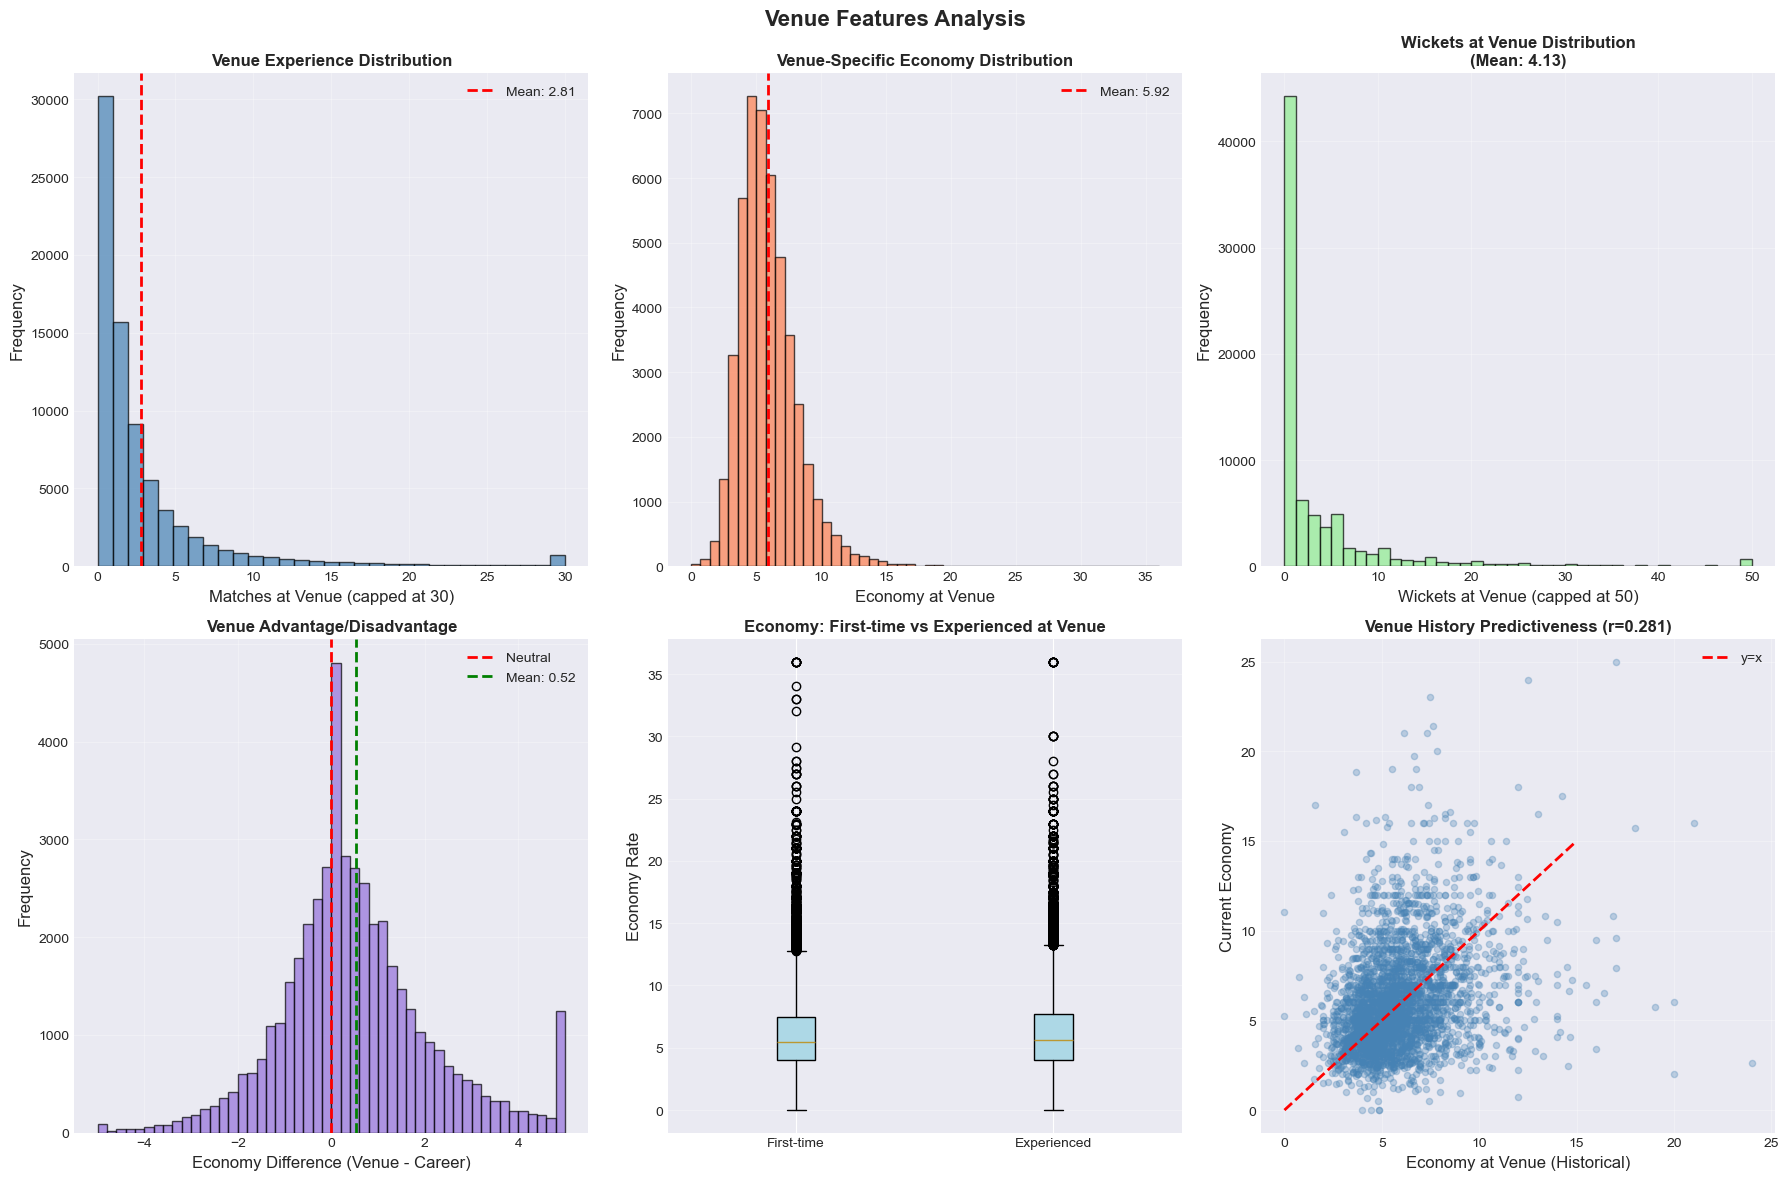



2.7 OPPONENT FEATURES ANALYSIS

📊 Opponent features available: 10

📊 Opponent familiarity:
   First-time vs opponent: 21,719 (28.2%)
   Opponent specialists (5+ matches): 27,185 (35.3%)
   Mean matches vs opponent: 5.53
   Max matches vs single opponent: 71

📊 Opponent-specific performance:
   Bowlers with opponent history: 55,312 (71.8%)
   Mean economy vs opponent: 5.77
   Correlation with current economy: 0.297

📊 Opponent strength:
   Matches vs Full Members: 48,926 (63.5%)
   Matches vs Top 8 teams: 40,500 (52.6%)
   Mean opponent batting strength: 37.43

📊 Matchup quality:
   Favorable matchups: 15,849 (28.7%)
   Unfavorable matchups: 38,292 (69.2%)

✅ Saved: eda_phase2_opponent_features.png


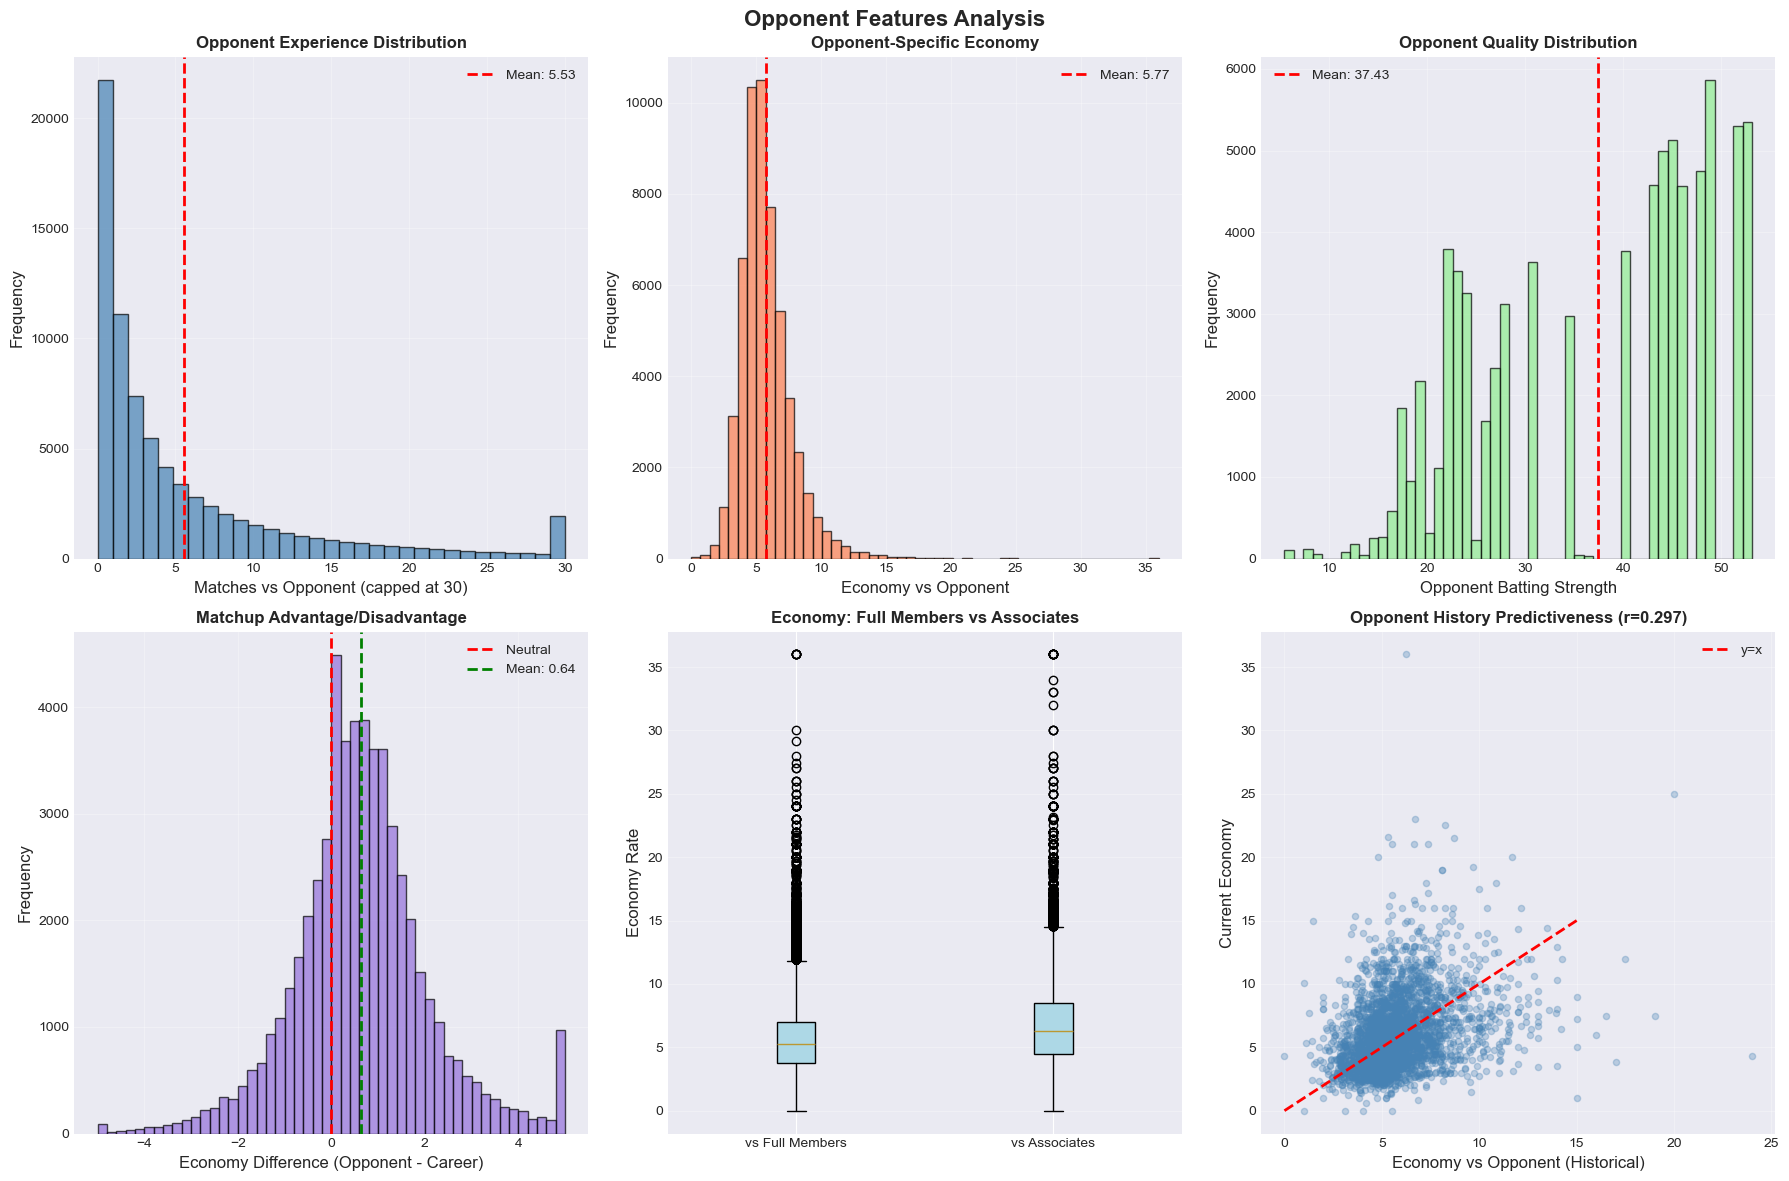



2.8 CONTEXT FEATURES ANALYSIS

📊 Home/Away analysis:
   Home matches: 23,937 (31.1%)
   Away matches: 53,094 (68.9%)
   Home economy: 5.81
   Away economy: 6.30
   Home advantage: 0.49 runs/over

📊 Bowling style distribution:
   right-arm offbreak: 12,469 (16.2%)
   right-arm fast-medium: 11,653 (15.1%)
   right-arm medium: 11,603 (15.1%)
   slow left-arm orthodox: 9,635 (12.5%)
   right-arm medium-fast: 8,204 (10.7%)
   right-arm fast: 6,006 (7.8%)
   legbreak: 3,109 (4.0%)
   left-arm fast-medium: 3,029 (3.9%)
   legbreak googly: 2,346 (3.0%)
   unknown: 1,776 (2.3%)

📊 Bowler age:
   Mean age: 28.5 years
   Median age: 28.4 years
   Age range: -0.5 - 86.8

✅ Saved: eda_phase2_context_features.png


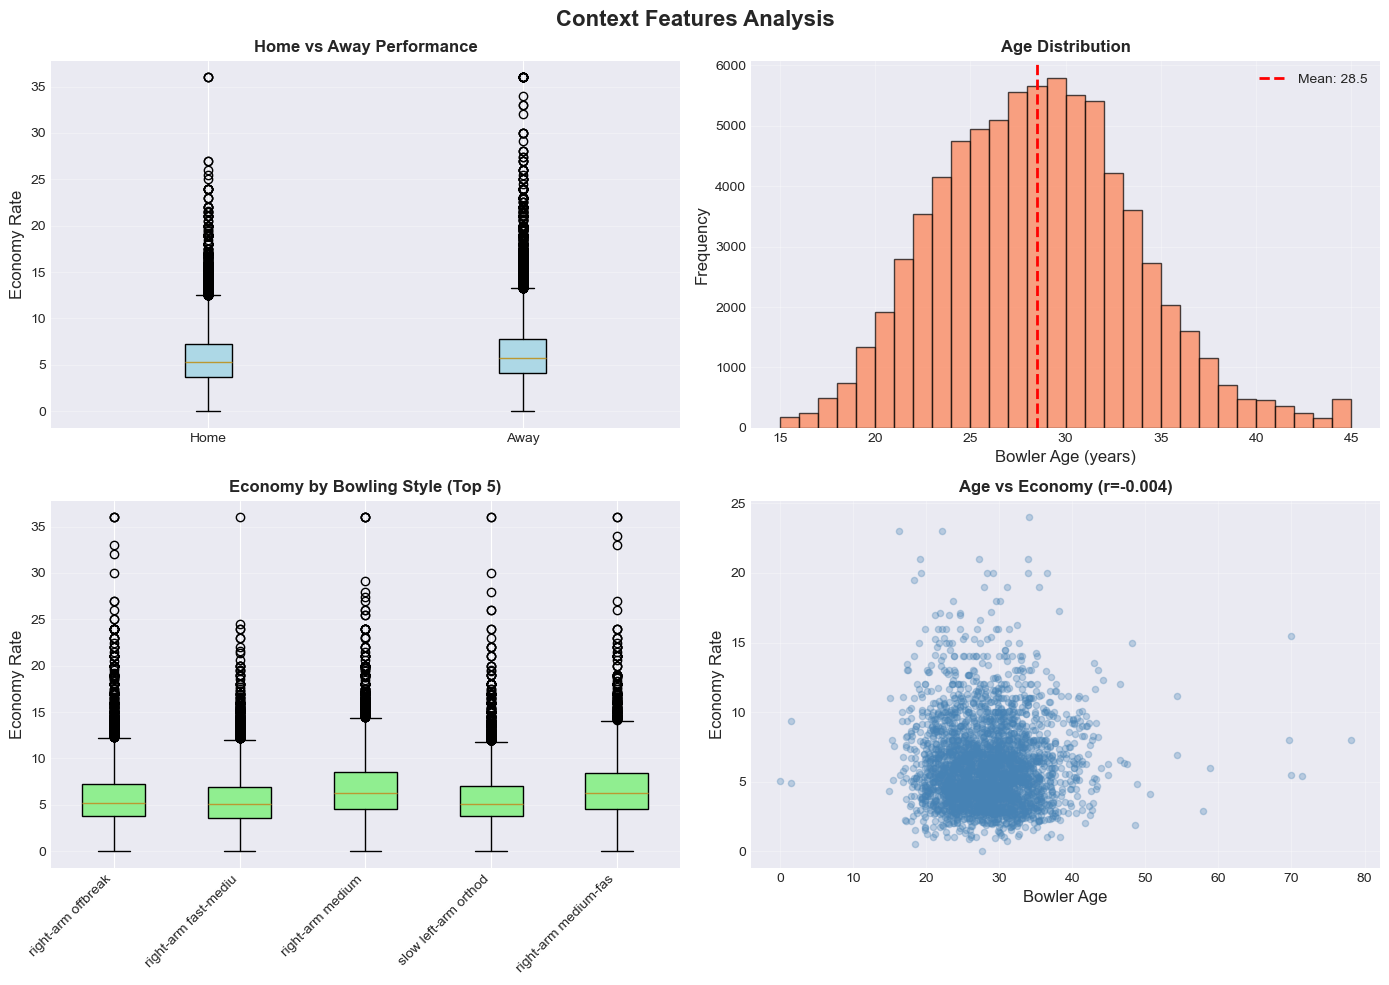



✅ EDA PHASE 2 COMPLETE - ALL SECTIONS

📊 COMPREHENSIVE FEATURE ANALYSIS SUMMARY:

1. CAREER FEATURES:
   ✓ Strongest predictor: career_dot_ball_pct (r=+0.42 with current dot%)
   ✓ Career economy moderately predictive (r=+0.33)
   ✓ 95.4% have prior match experience

2. FORM FEATURES:
   ✓ economy_last_5 correlation: 0.278
   ✓ 49.5% showing economy improvement
   ✓ 34.8% on wicket streaks

3. VENUE FEATURES:
   ✓ economy_at_venue correlation: 0.281
   ✓ 60.8% have venue history
   ✓ 16,881 favorable venue matchups

4. OPPONENT FEATURES:
   ✓ economy_vs_opponent correlation: 0.297
   ✓ 71.8% have opponent history
   ✓ 63.5% matches vs Full Members

5. CONTEXT FEATURES:
   ✓ Home advantage: 0.49 runs/over better
   ✓ Mean bowler age: 28.5 years
   ✓ Age-economy correlation: -0.004

📁 FILES CREATED:
   - eda_phase2_career_features.png
   - eda_phase2_career_vs_targets.png
   - eda_phase2_form_features.png
   - eda_phase2_venue_features.png
   - eda_phase2_opponent_features.png
   - eda

In [6]:
"""
EDA PHASE 2 - SECTION 3: VENUE & OPPONENT FEATURES
===================================================
Analyze venue familiarity and opponent matchup features
"""

print("\n\n" + "="*80)
print("2.6 VENUE FEATURES ANALYSIS")
print("="*80)

# ============================================================================
# 2.6 VENUE FEATURES
# ============================================================================

venue_features = [f for f in feature_groups['Venue Features'] if f in abt.columns]

print(f"\n📊 Venue features available: {len(venue_features)}")

# Venue experience distribution
print(f"\n📊 Venue familiarity:")
print(f"   First-time at venue: {abt['first_time_at_venue'].sum():,} ({abt['first_time_at_venue'].mean()*100:.1f}%)")
print(f"   Venue specialists (5+ matches): {abt['venue_specialist'].sum():,} ({abt['venue_specialist'].mean()*100:.1f}%)")
print(f"   Mean matches at venue: {abt['matches_at_venue'].mean():.2f}")
print(f"   Max matches at single venue: {abt['matches_at_venue'].max():.0f}")

# Venue performance
print(f"\n📊 Venue-specific performance:")
venue_perf = abt['economy_at_venue'].dropna()
print(f"   Bowlers with venue history: {len(venue_perf):,} ({len(venue_perf)/len(abt)*100:.1f}%)")
print(f"   Mean economy at venue: {venue_perf.mean():.2f}")
print(f"   Correlation with current economy: {abt['economy_at_venue'].corr(abt['economy_rate']):.3f}")

# Venue advantage/disadvantage
print(f"\n📊 Venue vs Career performance:")
venue_diff = abt['economy_vs_venue_avg'].dropna()
better_at_venue = (venue_diff < 0).sum()
worse_at_venue = (venue_diff > 0).sum()
print(f"   Better at venue: {better_at_venue:,} ({better_at_venue/len(venue_diff)*100:.1f}%)")
print(f"   Worse at venue: {worse_at_venue:,} ({worse_at_venue/len(venue_diff)*100:.1f}%)")
print(f"   Mean difference: {venue_diff.mean():.2f}")

# Visualize venue features
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Venue Features Analysis', fontsize=16, fontweight='bold')

# Matches at venue
ax = axes[0, 0]
data = abt['matches_at_venue'].clip(upper=30)
ax.hist(data, bins=31, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(abt['matches_at_venue'].mean(), color='red', linestyle='--', 
           linewidth=2, label=f'Mean: {abt["matches_at_venue"].mean():.2f}')
ax.set_xlabel('Matches at Venue (capped at 30)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Venue Experience Distribution', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Economy at venue
ax = axes[0, 1]
data = abt['economy_at_venue'].dropna()
ax.hist(data, bins=50, edgecolor='black', alpha=0.7, color='coral')
ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {data.mean():.2f}')
ax.set_xlabel('Economy at Venue', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Venue-Specific Economy Distribution', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Wickets at venue
ax = axes[0, 2]
data = abt['wickets_at_venue'].clip(upper=50)
ax.hist(data, bins=40, edgecolor='black', alpha=0.7, color='lightgreen')
ax.set_xlabel('Wickets at Venue (capped at 50)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title(f'Wickets at Venue Distribution\n(Mean: {abt["wickets_at_venue"].mean():.2f})', 
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Venue advantage/disadvantage
ax = axes[1, 0]
data = abt['economy_vs_venue_avg'].dropna().clip(-5, 5)
ax.hist(data, bins=50, edgecolor='black', alpha=0.7, color='mediumpurple')
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Neutral')
ax.axvline(data.mean(), color='green', linestyle='--', linewidth=2,
           label=f'Mean: {data.mean():.2f}')
ax.set_xlabel('Economy Difference (Venue - Career)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Venue Advantage/Disadvantage', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# First-time vs experienced at venue
ax = axes[1, 1]
first_time_econ = abt[abt['first_time_at_venue'] == 1]['economy_rate']
experienced_econ = abt[abt['first_time_at_venue'] == 0]['economy_rate']
bp = ax.boxplot([first_time_econ, experienced_econ], 
                 labels=['First-time', 'Experienced'],
                 patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax.set_ylabel('Economy Rate', fontsize=12)
ax.set_title('Economy: First-time vs Experienced at Venue', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Current economy vs venue history
ax = axes[1, 2]
sample = abt[abt['economy_at_venue'].notna()].sample(min(3000, len(abt[abt['economy_at_venue'].notna()])))
ax.scatter(sample['economy_at_venue'], sample['economy_rate'], 
           alpha=0.3, s=20, color='steelblue')
corr = abt['economy_at_venue'].corr(abt['economy_rate'])
ax.plot([0, 15], [0, 15], 'r--', linewidth=2, label='y=x')
ax.set_xlabel('Economy at Venue (Historical)', fontsize=12)
ax.set_ylabel('Current Economy', fontsize=12)
ax.set_title(f'Venue History Predictiveness (r={corr:.3f})', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_phase2_venue_features.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: eda_phase2_venue_features.png")
plt.show()

# ============================================================================
# 2.7 OPPONENT FEATURES
# ============================================================================
print("\n\n" + "="*80)
print("2.7 OPPONENT FEATURES ANALYSIS")
print("="*80)

opponent_features = [f for f in feature_groups['Opponent Features'] if f in abt.columns]

print(f"\n📊 Opponent features available: {len(opponent_features)}")

# Opponent experience
print(f"\n📊 Opponent familiarity:")
print(f"   First-time vs opponent: {abt['first_time_vs_opponent'].sum():,} ({abt['first_time_vs_opponent'].mean()*100:.1f}%)")
print(f"   Opponent specialists (5+ matches): {abt['opponent_specialist'].sum():,} ({abt['opponent_specialist'].mean()*100:.1f}%)")
print(f"   Mean matches vs opponent: {abt['matches_vs_opponent'].mean():.2f}")
print(f"   Max matches vs single opponent: {abt['matches_vs_opponent'].max():.0f}")

# Opponent performance
print(f"\n📊 Opponent-specific performance:")
opp_perf = abt['economy_vs_opponent'].dropna()
print(f"   Bowlers with opponent history: {len(opp_perf):,} ({len(opp_perf)/len(abt)*100:.1f}%)")
print(f"   Mean economy vs opponent: {opp_perf.mean():.2f}")
print(f"   Correlation with current economy: {abt['economy_vs_opponent'].corr(abt['economy_rate']):.3f}")

# Opponent strength
print(f"\n📊 Opponent strength:")
print(f"   Matches vs Full Members: {abt['opponent_is_full_member'].sum():,} ({abt['opponent_is_full_member'].mean()*100:.1f}%)")
print(f"   Matches vs Top 8 teams: {abt['opponent_is_top8'].sum():,} ({abt['opponent_is_top8'].mean()*100:.1f}%)")
print(f"   Mean opponent batting strength: {abt['opponent_batting_strength'].mean():.2f}")

# Matchup quality
print(f"\n📊 Matchup quality:")
matchup_diff = abt['economy_vs_opponent_diff'].dropna()
favorable = (matchup_diff < 0).sum()
unfavorable = (matchup_diff > 0).sum()
print(f"   Favorable matchups: {favorable:,} ({favorable/len(matchup_diff)*100:.1f}%)")
print(f"   Unfavorable matchups: {unfavorable:,} ({unfavorable/len(matchup_diff)*100:.1f}%)")

# Visualize opponent features
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Opponent Features Analysis', fontsize=16, fontweight='bold')

# Matches vs opponent
ax = axes[0, 0]
data = abt['matches_vs_opponent'].clip(upper=30)
ax.hist(data, bins=31, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(abt['matches_vs_opponent'].mean(), color='red', linestyle='--',
           linewidth=2, label=f'Mean: {abt["matches_vs_opponent"].mean():.2f}')
ax.set_xlabel('Matches vs Opponent (capped at 30)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Opponent Experience Distribution', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Economy vs opponent
ax = axes[0, 1]
data = abt['economy_vs_opponent'].dropna()
ax.hist(data, bins=50, edgecolor='black', alpha=0.7, color='coral')
ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {data.mean():.2f}')
ax.set_xlabel('Economy vs Opponent', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Opponent-Specific Economy', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Opponent batting strength
ax = axes[0, 2]
data = abt['opponent_batting_strength']
ax.hist(data, bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {data.mean():.2f}')
ax.set_xlabel('Opponent Batting Strength', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Opponent Quality Distribution', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Matchup advantage/disadvantage
ax = axes[1, 0]
data = abt['economy_vs_opponent_diff'].dropna().clip(-5, 5)
ax.hist(data, bins=50, edgecolor='black', alpha=0.7, color='mediumpurple')
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Neutral')
ax.axvline(data.mean(), color='green', linestyle='--', linewidth=2,
           label=f'Mean: {data.mean():.2f}')
ax.set_xlabel('Economy Difference (Opponent - Career)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Matchup Advantage/Disadvantage', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Economy by opponent type
ax = axes[1, 1]
full_member_econ = abt[abt['opponent_is_full_member'] == 1]['economy_rate']
associate_econ = abt[abt['opponent_is_full_member'] == 0]['economy_rate']
bp = ax.boxplot([full_member_econ, associate_econ],
                 labels=['vs Full Members', 'vs Associates'],
                 patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax.set_ylabel('Economy Rate', fontsize=12)
ax.set_title('Economy: Full Members vs Associates', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Current economy vs opponent history
ax = axes[1, 2]
sample = abt[abt['economy_vs_opponent'].notna()].sample(min(3000, len(abt[abt['economy_vs_opponent'].notna()])))
ax.scatter(sample['economy_vs_opponent'], sample['economy_rate'],
           alpha=0.3, s=20, color='steelblue')
corr = abt['economy_vs_opponent'].corr(abt['economy_rate'])
ax.plot([0, 15], [0, 15], 'r--', linewidth=2, label='y=x')
ax.set_xlabel('Economy vs Opponent (Historical)', fontsize=12)
ax.set_ylabel('Current Economy', fontsize=12)
ax.set_title(f'Opponent History Predictiveness (r={corr:.3f})', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_phase2_opponent_features.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: eda_phase2_opponent_features.png")
plt.show()

# ============================================================================
# 2.8 CONTEXT FEATURES
# ============================================================================
print("\n\n" + "="*80)
print("2.8 CONTEXT FEATURES ANALYSIS")
print("="*80)

# Home/away advantage
print(f"\n📊 Home/Away analysis:")
home_matches = abt[abt['is_home_match'] == 1]
away_matches = abt[abt['is_home_match'] == 0]
print(f"   Home matches: {len(home_matches):,} ({len(home_matches)/len(abt)*100:.1f}%)")
print(f"   Away matches: {len(away_matches):,} ({len(away_matches)/len(abt)*100:.1f}%)")
print(f"   Home economy: {home_matches['economy_rate'].mean():.2f}")
print(f"   Away economy: {away_matches['economy_rate'].mean():.2f}")
print(f"   Home advantage: {away_matches['economy_rate'].mean() - home_matches['economy_rate'].mean():.2f} runs/over")

# Bowling style
print(f"\n📊 Bowling style distribution:")
style_counts = abt['bowler_bowling_style'].value_counts().head(10)
for style, count in style_counts.items():
    print(f"   {style}: {count:,} ({count/len(abt)*100:.1f}%)")

# Age analysis
print(f"\n📊 Bowler age:")
age_data = abt['bowler_age_at_match'].dropna()
print(f"   Mean age: {age_data.mean():.1f} years")
print(f"   Median age: {age_data.median():.1f} years")
print(f"   Age range: {age_data.min():.1f} - {age_data.max():.1f}")

# Visualize context features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Context Features Analysis', fontsize=16, fontweight='bold')

# Home vs Away economy
ax = axes[0, 0]
bp = ax.boxplot([home_matches['economy_rate'], away_matches['economy_rate']],
                 labels=['Home', 'Away'], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax.set_ylabel('Economy Rate', fontsize=12)
ax.set_title('Home vs Away Performance', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Age distribution
ax = axes[0, 1]
age_data_capped = age_data.clip(15, 45)
ax.hist(age_data_capped, bins=30, edgecolor='black', alpha=0.7, color='coral')
ax.axvline(age_data.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {age_data.mean():.1f}')
ax.set_xlabel('Bowler Age (years)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Age Distribution', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Economy by bowling style (top 5)
ax = axes[1, 0]
top_styles = abt['bowler_bowling_style'].value_counts().head(5).index
style_economies = [abt[abt['bowler_bowling_style'] == style]['economy_rate'] for style in top_styles]
bp = ax.boxplot(style_economies, labels=[s[:20] for s in top_styles], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightgreen')
ax.set_ylabel('Economy Rate', fontsize=12)
ax.set_title('Economy by Bowling Style (Top 5)', fontsize=12, fontweight='bold')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

# Age vs Economy
ax = axes[1, 1]
sample = abt[abt['bowler_age_at_match'].notna()].sample(min(3000, len(abt[abt['bowler_age_at_match'].notna()])))
ax.scatter(sample['bowler_age_at_match'], sample['economy_rate'],
           alpha=0.3, s=20, color='steelblue')
corr = abt['bowler_age_at_match'].corr(abt['economy_rate'])
ax.set_xlabel('Bowler Age', fontsize=12)
ax.set_ylabel('Economy Rate', fontsize=12)
ax.set_title(f'Age vs Economy (r={corr:.3f})', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_phase2_context_features.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: eda_phase2_context_features.png")
plt.show()

# ============================================================================
# PHASE 2 COMPLETE SUMMARY
# ============================================================================
print("\n\n" + "="*80)
print("✅ EDA PHASE 2 COMPLETE - ALL SECTIONS")
print("="*80)

print("\n📊 COMPREHENSIVE FEATURE ANALYSIS SUMMARY:")
print("="*80)

print("\n1. CAREER FEATURES:")
print(f"   ✓ Strongest predictor: career_dot_ball_pct (r=+0.42 with current dot%)")
print(f"   ✓ Career economy moderately predictive (r=+0.33)")
print(f"   ✓ 95.4% have prior match experience")

print("\n2. FORM FEATURES:")
print(f"   ✓ economy_last_5 correlation: {abt['economy_last_5'].corr(abt['economy_rate']):.3f}")
print(f"   ✓ 49.5% showing economy improvement")
print(f"   ✓ 34.8% on wicket streaks")

print("\n3. VENUE FEATURES:")
venue_econ_corr = abt['economy_at_venue'].corr(abt['economy_rate'])
print(f"   ✓ economy_at_venue correlation: {venue_econ_corr:.3f}")
print(f"   ✓ 60.8% have venue history")
print(f"   ✓ {(abt['economy_vs_venue_avg'] < 0).sum():,} favorable venue matchups")

print("\n4. OPPONENT FEATURES:")
opp_econ_corr = abt['economy_vs_opponent'].corr(abt['economy_rate'])
print(f"   ✓ economy_vs_opponent correlation: {opp_econ_corr:.3f}")
print(f"   ✓ 71.8% have opponent history")
print(f"   ✓ 63.5% matches vs Full Members")

print("\n5. CONTEXT FEATURES:")
print(f"   ✓ Home advantage: {away_matches['economy_rate'].mean() - home_matches['economy_rate'].mean():.2f} runs/over better")
print(f"   ✓ Mean bowler age: {age_data.mean():.1f} years")
print(f"   ✓ Age-economy correlation: {abt['bowler_age_at_match'].corr(abt['economy_rate']):.3f}")

print("\n📁 FILES CREATED:")
print("   - eda_phase2_career_features.png")
print("   - eda_phase2_career_vs_targets.png")
print("   - eda_phase2_form_features.png")
print("   - eda_phase2_venue_features.png")
print("   - eda_phase2_opponent_features.png")
print("   - eda_phase2_context_features.png")

print("\n🎯 MODELING INSIGHTS:")
print("   • Career stats provide strong baseline")
print("   • Recent form critical (especially last 5 matches)")
print("   • Venue & opponent history moderately predictive")
print("   • Home advantage exists but modest")
print("   • Format-specific models essential (different dynamics)")

print("\n🚀 READY FOR PHASE 3: FEATURE IMPORTANCE & CORRELATIONS")
print("="*80)


📊 EDA PHASE 3: FEATURE IMPORTANCE & CORRELATION ANALYSIS

📊 Loading ABT...
✅ Loaded: 77,031 rows, 161 columns


--------------------------------------------------------------------------------
3.1 PREPARING FEATURES FOR IMPORTANCE ANALYSIS
--------------------------------------------------------------------------------

📊 Features selected for analysis: 43

📊 Handling missing values...
   Rows before: 77,031
   Rows after: 77,031
   Encoded 2 categorical features


--------------------------------------------------------------------------------
3.2 RANDOM FOREST FEATURE IMPORTANCE
--------------------------------------------------------------------------------

📊 Training Random Forest for feature importance...
   Training on 77,031 samples
   Features: 43
   Target: economy_rate

   Training...
✅ Model trained! R² score: 0.413

📊 TOP 20 MOST IMPORTANT FEATURES:
   career_economy_t20................................ 0.4331
   match_type........................................ 0.1661
  

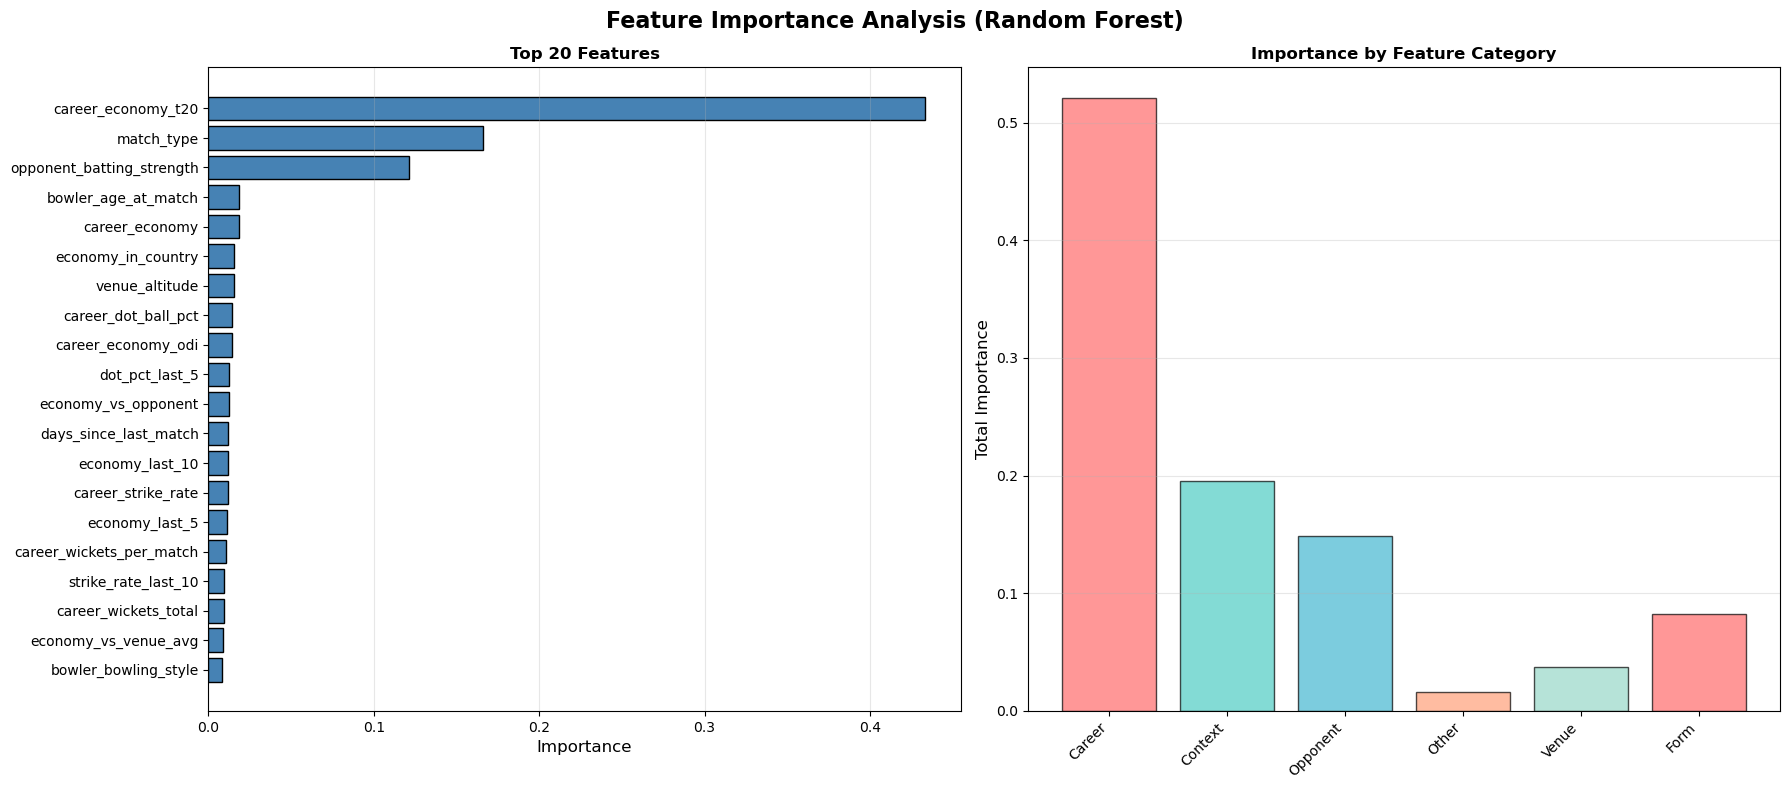



--------------------------------------------------------------------------------
3.3 COMPREHENSIVE CORRELATION ANALYSIS
--------------------------------------------------------------------------------

📊 Correlation with target (economy_rate):
   career_economy_t20................................ +0.427
   dot_pct_last_5.................................... -0.291
   career_dot_ball_pct............................... -0.287
   career_economy.................................... +0.283
   economy_last_10................................... +0.282
   economy_last_5.................................... +0.278
   economy_in_country................................ +0.254
   strike_rate_last_10............................... -0.237
   strike_rate_last_5................................ -0.222
   career_economy_odi................................ -0.197
   career_strike_rate................................ -0.182
   career_wickets_per_match.......................... -0.175
   opponent_batting_st

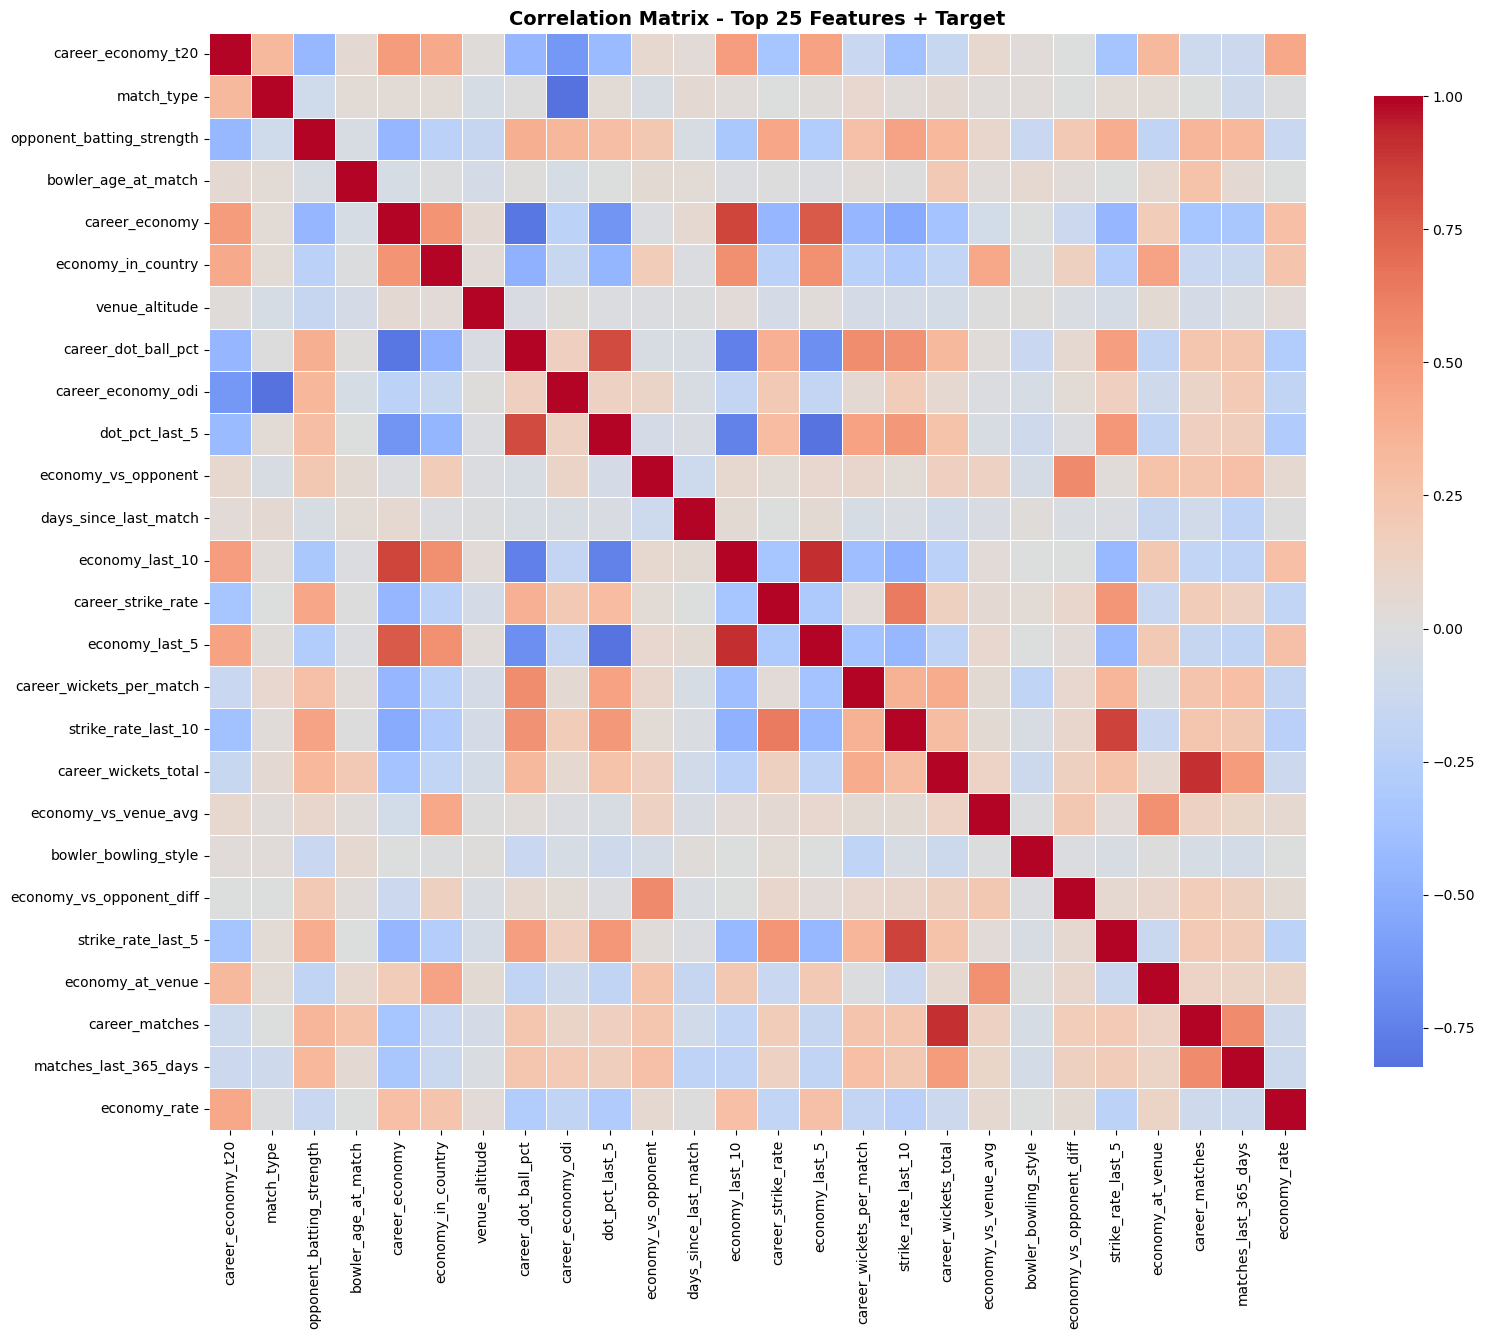



3.4 FEATURE SELECTION RECOMMENDATIONS

📊 Feature importance tiers:
   HIGH importance (>0.02): 3 features
   MEDIUM importance (0.01-0.02): 13 features
   LOW importance (<0.01): 27 features

✅ RECOMMENDED FEATURES FOR MODELING:

   MUST INCLUDE (High importance):
      • career_economy_t20
      • match_type
      • opponent_batting_strength

   CONSIDER INCLUDING (Medium importance):
      • bowler_age_at_match
      • career_economy
      • economy_in_country
      • venue_altitude
      • career_dot_ball_pct
      • career_economy_odi
      • dot_pct_last_5
      • economy_vs_opponent
      • days_since_last_match
      • economy_last_10

   CAN DROP (Low importance):
      • strike_rate_last_10
      • career_wickets_total
      • economy_vs_venue_avg
      • bowler_bowling_style
      • economy_vs_opponent_diff
      • strike_rate_last_5
      • economy_at_venue
      • career_matches
      • matches_last_365_days
      • wickets_last_10


--------------------------------------

In [1]:
"""
EDA PHASE 3: FEATURE IMPORTANCE & CORRELATION ANALYSIS
=======================================================
Final comprehensive analysis before modeling
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("\n" + "="*80)
print("📊 EDA PHASE 3: FEATURE IMPORTANCE & CORRELATION ANALYSIS")
print("="*80)

# ============================================================================
# 0. LOAD DATA
# ============================================================================
print("\n📊 Loading ABT...")
abt = pd.read_parquet('abt_final_with_all_features.parquet')
print(f"✅ Loaded: {len(abt):,} rows, {len(abt.columns)} columns")

# ============================================================================
# 3.1 PREPARE FEATURES FOR IMPORTANCE ANALYSIS
# ============================================================================
print("\n\n" + "-"*80)
print("3.1 PREPARING FEATURES FOR IMPORTANCE ANALYSIS")
print("-"*80)

# Select key predictive features (excluding identifiers and post-match variables)
feature_candidates = [
    # Format
    'match_type',
    
    # Career aggregates
    'career_matches', 'career_economy', 'career_wickets_total',
    'career_strike_rate', 'career_dot_ball_pct', 'career_wickets_per_match',
    'career_economy_t20', 'career_economy_odi', 'career_economy_test',
    
    # Form (rolling windows)
    'wickets_last_5', 'economy_last_5', 'strike_rate_last_5', 'dot_pct_last_5',
    'wickets_last_10', 'economy_last_10', 'strike_rate_last_10',
    'economy_improving', 'wicket_streak',
    
    # Venue
    'matches_at_venue', 'economy_at_venue', 'wickets_at_venue',
    'economy_in_country', 'first_time_at_venue', 'venue_specialist',
    'economy_vs_venue_avg', 'venue_altitude',
    
    # Opponent
    'matches_vs_opponent', 'economy_vs_opponent', 'wickets_vs_opponent',
    'opponent_batting_strength', 'opponent_is_full_member', 'opponent_is_top8',
    'first_time_vs_opponent', 'opponent_specialist', 'economy_vs_opponent_diff',
    
    # Context
    'is_home_match', 'bowler_bowling_style', 'bowler_age_at_match',
    'days_since_last_match', 'matches_last_365_days', 'is_debut',
    'bowling_team_won_toss'
]

# Keep only features that exist
available_features = [f for f in feature_candidates if f in abt.columns]
print(f"\n📊 Features selected for analysis: {len(available_features)}")

# Prepare data - drop rows with missing targets
target = 'economy_rate'
analysis_data = abt[available_features + [target]].copy()

# Fill missing values strategically
print(f"\n📊 Handling missing values...")
print(f"   Rows before: {len(analysis_data):,}")

# Fill career features with 0 (debuts)
career_cols = [c for c in analysis_data.columns if 'career_' in c or 'last_' in c]
for col in career_cols:
    if col in analysis_data.columns:
        analysis_data[col] = analysis_data[col].fillna(0)

# Fill venue/opponent features with 0 (first time)
venue_opp_cols = [c for c in analysis_data.columns if 'venue' in c.lower() or 'opponent' in c.lower()]
for col in venue_opp_cols:
    if col in analysis_data.columns and analysis_data[col].dtype in ['float64', 'int64']:
        analysis_data[col] = analysis_data[col].fillna(0)

# Fill remaining numeric with median
numeric_cols = analysis_data.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if analysis_data[col].isna().any():
        analysis_data[col] = analysis_data[col].fillna(analysis_data[col].median())

# Drop any remaining rows with missing values
analysis_data = analysis_data.dropna()
print(f"   Rows after: {len(analysis_data):,}")

# Encode categorical variables
categorical_cols = analysis_data.select_dtypes(include=['object']).columns
le_dict = {}
for col in categorical_cols:
    if col != target:
        le = LabelEncoder()
        analysis_data[col] = le.fit_transform(analysis_data[col].astype(str))
        le_dict[col] = le

print(f"   Encoded {len(categorical_cols)} categorical features")

# ============================================================================
# 3.2 RANDOM FOREST FEATURE IMPORTANCE
# ============================================================================
print("\n\n" + "-"*80)
print("3.2 RANDOM FOREST FEATURE IMPORTANCE")
print("-"*80)

print(f"\n📊 Training Random Forest for feature importance...")
print(f"   Training on {len(analysis_data):,} samples")

# Prepare X and y
X = analysis_data.drop(columns=[target])
y = analysis_data[target]

print(f"   Features: {X.shape[1]}")
print(f"   Target: {target}")

# Train Random Forest (quick version)
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

print(f"\n   Training...")
rf.fit(X, y)
print(f"✅ Model trained! R² score: {rf.score(X, y):.3f}")

# Get feature importances
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n📊 TOP 20 MOST IMPORTANT FEATURES:")
print("="*80)
for idx, row in importances.head(20).iterrows():
    print(f"   {row['Feature']:.<50} {row['Importance']:.4f}")

# Visualize feature importance
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Feature Importance Analysis (Random Forest)', fontsize=16, fontweight='bold')

# Top 20
ax = axes[0]
top20 = importances.head(20)
ax.barh(range(len(top20)), top20['Importance'], color='steelblue', edgecolor='black')
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['Feature'], fontsize=10)
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Top 20 Features', fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# By category
ax = axes[1]
category_importance = {}
for idx, row in importances.iterrows():
    feat = row['Feature']
    imp = row['Importance']
    
    if 'career_' in feat or 'is_debut' in feat:
        category = 'Career'
    elif 'last_' in feat or 'improving' in feat or 'streak' in feat:
        category = 'Form'
    elif 'venue' in feat.lower() or 'altitude' in feat:
        category = 'Venue'
    elif 'opponent' in feat.lower():
        category = 'Opponent'
    elif feat in ['match_type', 'is_home_match', 'bowler_bowling_style', 
                   'bowler_age_at_match', 'days_since_last_match', 
                   'matches_last_365_days', 'bowling_team_won_toss']:
        category = 'Context'
    else:
        category = 'Other'
    
    category_importance[category] = category_importance.get(category, 0) + imp

categories = list(category_importance.keys())
values = list(category_importance.values())
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
ax.bar(categories, values, color=colors[:len(categories)], edgecolor='black', alpha=0.7)
ax.set_ylabel('Total Importance', fontsize=12)
ax.set_title('Importance by Feature Category', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('eda_phase3_feature_importance.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: eda_phase3_feature_importance.png")
plt.show()

# ============================================================================
# 3.3 COMPREHENSIVE CORRELATION MATRIX
# ============================================================================
print("\n\n" + "-"*80)
print("3.3 COMPREHENSIVE CORRELATION ANALYSIS")
print("-"*80)

# Select top features for correlation
top_features = importances.head(25)['Feature'].tolist() + [target]
corr_data = analysis_data[top_features]

# Compute correlation matrix
corr_matrix = corr_data.corr()

print(f"\n📊 Correlation with target ({target}):")
print("="*80)
target_corr = corr_matrix[target].drop(target).sort_values(ascending=False, key=abs)
for feat, corr in target_corr.head(15).items():
    print(f"   {feat:.<50} {corr:+.3f}")

# Find highly correlated feature pairs (multicollinearity)
print(f"\n📊 High correlations between features (potential multicollinearity):")
print("="*80)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

if len(high_corr_pairs) > 0:
    for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:10]:
        print(f"   {feat1} ↔ {feat2}: {corr:.3f}")
else:
    print("   No high correlations found (good!)")

# Visualize correlation matrix
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Matrix - Top 25 Features + Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_phase3_correlation_matrix.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: eda_phase3_correlation_matrix.png")
plt.show()

# ============================================================================
# 3.4 FEATURE SELECTION RECOMMENDATIONS
# ============================================================================
print("\n\n" + "="*80)
print("3.4 FEATURE SELECTION RECOMMENDATIONS")
print("="*80)

# Categorize features by importance
high_importance = importances[importances['Importance'] > 0.02]
medium_importance = importances[(importances['Importance'] > 0.01) & (importances['Importance'] <= 0.02)]
low_importance = importances[importances['Importance'] <= 0.01]

print(f"\n📊 Feature importance tiers:")
print(f"   HIGH importance (>0.02): {len(high_importance)} features")
print(f"   MEDIUM importance (0.01-0.02): {len(medium_importance)} features")
print(f"   LOW importance (<0.01): {len(low_importance)} features")

print(f"\n✅ RECOMMENDED FEATURES FOR MODELING:")
print("="*80)
print(f"\n   MUST INCLUDE (High importance):")
for feat in high_importance['Feature'][:15]:
    print(f"      • {feat}")

print(f"\n   CONSIDER INCLUDING (Medium importance):")
for feat in medium_importance['Feature'][:10]:
    print(f"      • {feat}")

print(f"\n   CAN DROP (Low importance):")
if len(low_importance) > 0:
    for feat in low_importance['Feature'][:10]:
        print(f"      • {feat}")
else:
    print(f"      None - all features have reasonable importance!")

# ============================================================================
# 3.5 FORMAT-SPECIFIC ANALYSIS
# ============================================================================
print("\n\n" + "-"*80)
print("3.5 FORMAT-SPECIFIC FEATURE IMPORTANCE")
print("-"*80)

for format_type in ['T20', 'ODI', 'Test']:
    format_data = analysis_data[analysis_data['match_type'] == format_type]
    
    if len(format_data) < 100:
        continue
    
    print(f"\n📊 {format_type} FORMAT:")
    print(f"   Samples: {len(format_data):,}")
    
    X_fmt = format_data.drop(columns=[target, 'match_type'])
    y_fmt = format_data[target]
    
    rf_fmt = RandomForestRegressor(n_estimators=50, max_depth=8, random_state=42, n_jobs=-1)
    rf_fmt.fit(X_fmt, y_fmt)
    
    fmt_importance = pd.DataFrame({
        'Feature': X_fmt.columns,
        'Importance': rf_fmt.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print(f"   Top 5 features:")
    for idx, row in fmt_importance.head(5).iterrows():
        print(f"      {row['Feature']:.<40} {row['Importance']:.4f}")

# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n\n" + "="*80)
print("✅ EDA PHASE 3 COMPLETE - FEATURE IMPORTANCE & CORRELATIONS")
print("="*80)

print("\n📊 KEY INSIGHTS:")
print("-"*80)

print(f"\n1. MOST IMPORTANT FEATURES:")
print(f"   Top 3: {', '.join(importances.head(3)['Feature'].tolist())}")

print(f"\n2. FEATURE CATEGORIES BY IMPORTANCE:")
for cat, imp in sorted(category_importance.items(), key=lambda x: x[1], reverse=True):
    print(f"   {cat}: {imp:.3f}")

print(f"\n3. MULTICOLLINEARITY:")
if len(high_corr_pairs) > 0:
    print(f"   Found {len(high_corr_pairs)} highly correlated pairs")
    print(f"   Action: Consider removing one feature from each pair")
else:
    print(f"   ✓ No major multicollinearity issues")

print(f"\n4. RECOMMENDED FEATURE COUNT:")
print(f"   Minimum viable: ~15 features (high importance only)")
print(f"   Recommended: ~30 features (high + medium importance)")
print(f"   Maximum: ~{len(importances[importances['Importance'] > 0.005])} features (all meaningful)")

print(f"\n📁 FILES CREATED:")
print("   - eda_phase3_feature_importance.png")
print("   - eda_phase3_correlation_matrix.png")

print(f"\n🎯 MODELING READINESS:")
print("   ✓ Features identified and ranked")
print("   ✓ Multicollinearity checked")
print("   ✓ Format-specific differences understood")
print("   ✓ Target correlations known")

print(f"\n🚀 READY FOR MODELING!")
print(f"   Next: Build baseline models (Random Forest, XGBoost)")
print("="*80)


🎯 CRICKET BOWLER PERFORMANCE PREDICTION - MODELING PHASE

--------------------------------------------------------------------------------
STEP 1: LOADING DATA
--------------------------------------------------------------------------------
✅ Loaded ABT: 77,031 rows, 161 columns

📊 Data range:
   Start: 2001-12-19 00:00:00
   End: 2025-12-29 00:00:00

--------------------------------------------------------------------------------
STEP 2: TEMPORAL TRAIN/VALIDATION/TEST SPLIT
--------------------------------------------------------------------------------

📊 Split summary:
   TRAIN (≤ 2023): 60,103 rows (78.0%)
   VAL (2024):     8,887 rows (11.5%)
   TEST (2025):    8,041 rows (10.4%)

📊 Format distribution in splits:
   TRAIN: T20=23,304, ODI=27,648, Test=9,151
   VAL: T20=7,244, ODI=1,080, Test=563
   TEST: T20=6,281, ODI=1,292, Test=468

--------------------------------------------------------------------------------
STEP 3: FEATURE SELECTION
---------------------------------------

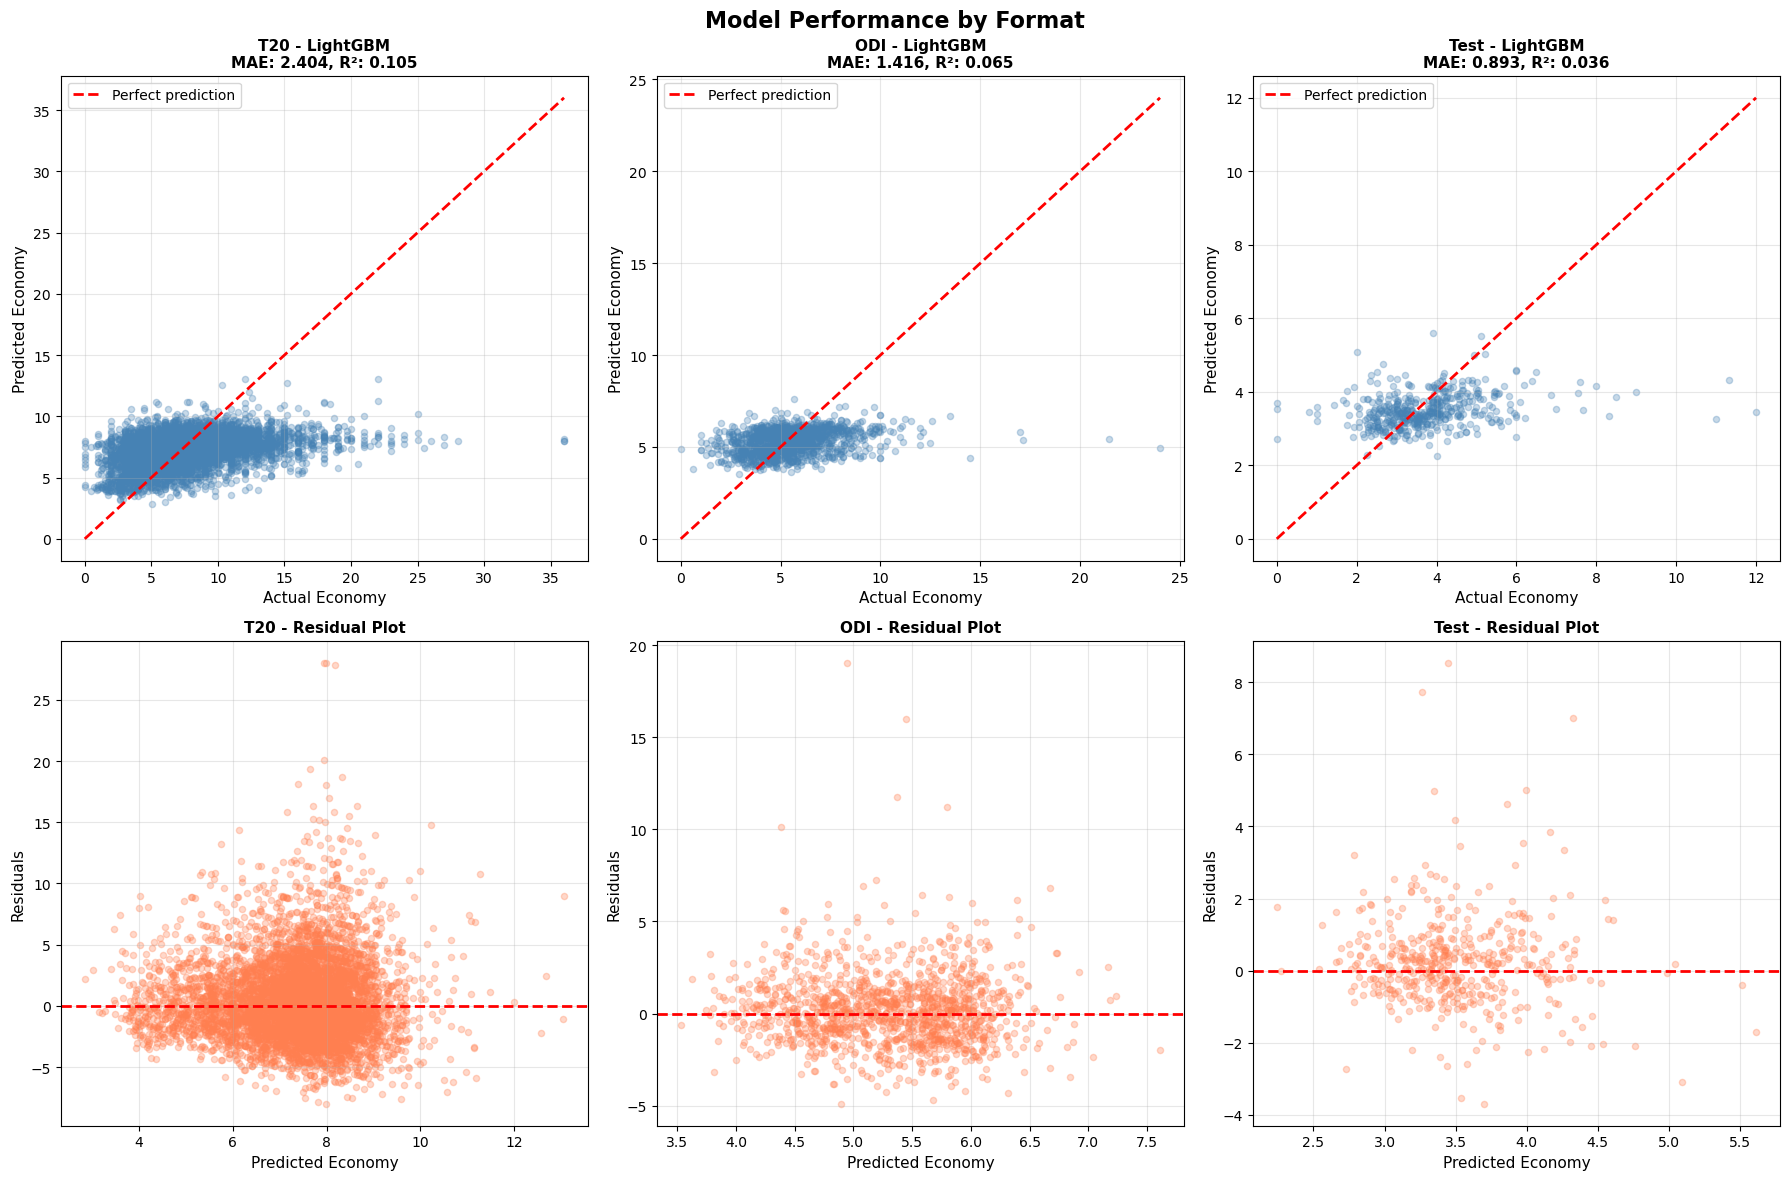


📊 FEATURE IMPORTANCE (BEST MODELS)

💾 Saved: modeling_feature_importance_by_format.png


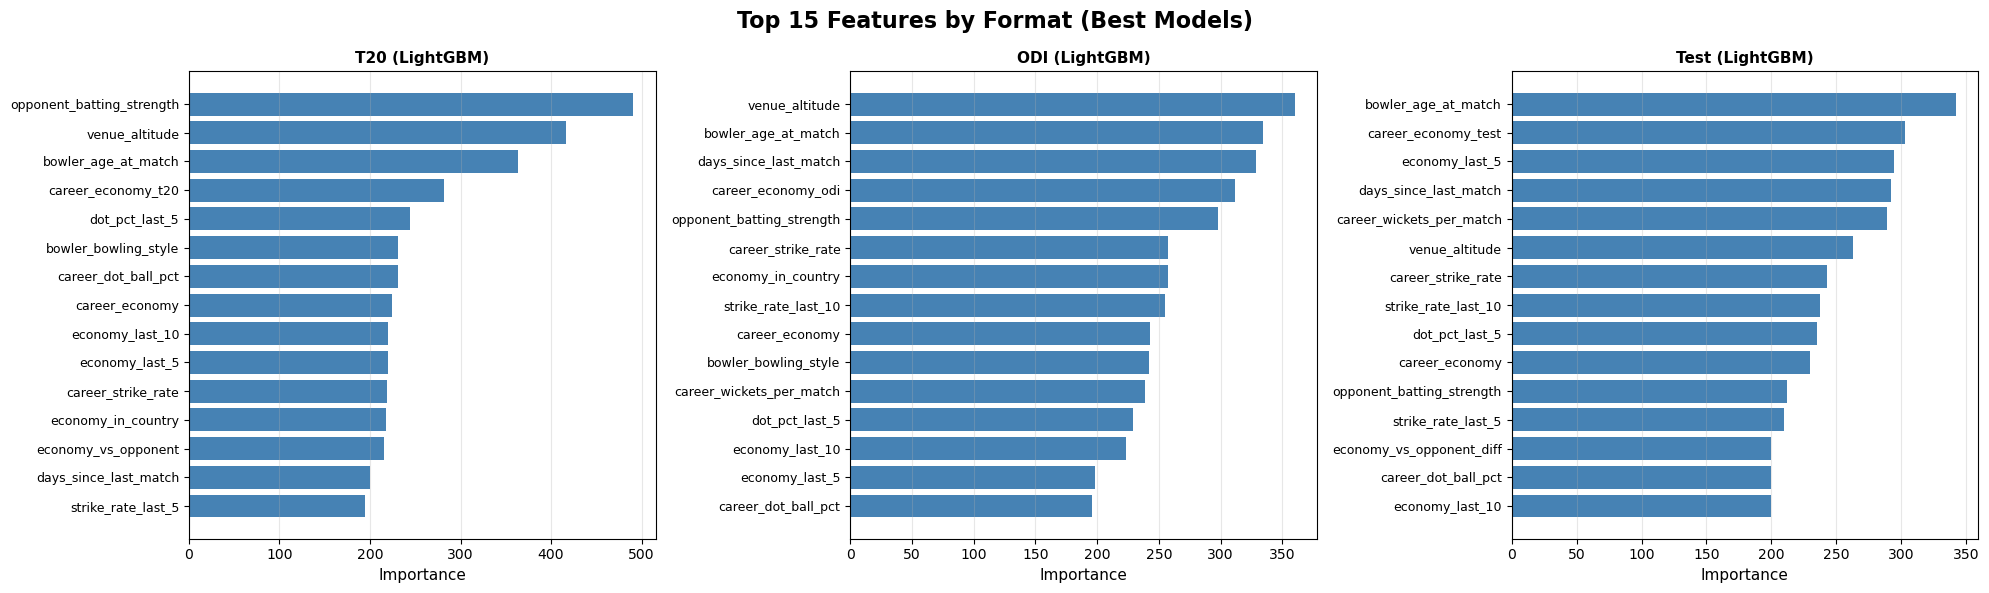



✅ MODELING COMPLETE!

🎯 BEST MODELS TRAINED:
   T20............ LightGBM....... Test MAE: 2.404, R²: 0.105
   ODI............ LightGBM....... Test MAE: 1.416, R²: 0.065
   Test........... LightGBM....... Test MAE: 0.893, R²: 0.036

💾 SAVED FILES:
   - model_t20_best.pkl
   - model_odi_best.pkl
   - model_test_best.pkl
   - modeling_results_by_format.png
   - modeling_feature_importance_by_format.png

🎯 PERFORMANCE INTERPRETATION:
   Average Test MAE: 1.571 runs/over
   This means predictions are off by ~1.57 runs/over on average

🚀 NEXT STEPS:
   ✓ Models trained and saved
   ✓ Can now make predictions on new data
   ✓ Consider hyperparameter tuning for further improvements
   ✓ Explore other targets (wickets, strike_rate, dot_ball_percentage)


In [7]:
"""
CRICKET BOWLER PERFORMANCE PREDICTION - MODELING PHASE (FIXED)
===============================================================
Complete modeling pipeline with format-specific models
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import lightgbm as lgb
import joblib
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("\n" + "="*80)
print("🎯 CRICKET BOWLER PERFORMANCE PREDICTION - MODELING PHASE")
print("="*80)

# ============================================================================
# STEP 1: LOAD DATA & PREPARE
# ============================================================================
print("\n" + "-"*80)
print("STEP 1: LOADING DATA")
print("-"*80)

abt = pd.read_parquet('abt_final_with_all_features.parquet')
print(f"✅ Loaded ABT: {len(abt):,} rows, {len(abt.columns)} columns")

# Convert date to datetime (FIXED: correct column name is 'date')
abt['date'] = pd.to_datetime(abt['date'])

print(f"\n📊 Data range:")
print(f"   Start: {abt['date'].min()}")
print(f"   End: {abt['date'].max()}")

# ============================================================================
# STEP 2: TEMPORAL TRAIN/VAL/TEST SPLIT
# ============================================================================
print("\n" + "-"*80)
print("STEP 2: TEMPORAL TRAIN/VALIDATION/TEST SPLIT")
print("-"*80)

# Define split dates (TEMPORAL - no data leakage!)
train_end = '2023-12-31'
val_end = '2024-12-31'

train_data = abt[abt['date'] <= train_end].copy()
val_data = abt[(abt['date'] > train_end) & (abt['date'] <= val_end)].copy()
test_data = abt[abt['date'] > val_end].copy()

print(f"\n📊 Split summary:")
print(f"   TRAIN (≤ 2023): {len(train_data):,} rows ({len(train_data)/len(abt)*100:.1f}%)")
print(f"   VAL (2024):     {len(val_data):,} rows ({len(val_data)/len(abt)*100:.1f}%)")
print(f"   TEST (2025):    {len(test_data):,} rows ({len(test_data)/len(abt)*100:.1f}%)")

print(f"\n📊 Format distribution in splits:")
for split_name, split_df in [('TRAIN', train_data), ('VAL', val_data), ('TEST', test_data)]:
    fmt_dist = split_df['match_type'].value_counts()
    print(f"   {split_name}: T20={fmt_dist.get('T20', 0):,}, ODI={fmt_dist.get('ODI', 0):,}, Test={fmt_dist.get('Test', 0):,}")

# ============================================================================
# STEP 3: FEATURE SELECTION (from Phase 3 EDA)
# ============================================================================
print("\n" + "-"*80)
print("STEP 3: FEATURE SELECTION")
print("-"*80)

# Based on EDA Phase 3 - top features by importance
selected_features = [
    # Format (will be dropped after split)
    'match_type',
    
    # Career aggregates (HIGH importance)
    'career_economy', 'career_dot_ball_pct', 'career_wickets_total',
    'career_strike_rate', 'career_matches', 'career_wickets_per_match',
    'career_economy_t20', 'career_economy_odi', 'career_economy_test',
    'career_wickets_t20', 'career_wickets_odi', 'career_wickets_test',
    
    # Form features (HIGH importance)
    'economy_last_5', 'wickets_last_5', 'dot_pct_last_5', 'strike_rate_last_5',
    'economy_last_10', 'wickets_last_10', 'strike_rate_last_10',
    'economy_improving', 'wicket_streak',
    
    # Venue features (MEDIUM importance)
    'matches_at_venue', 'economy_at_venue', 'wickets_at_venue',
    'economy_in_country', 'first_time_at_venue', 'venue_specialist',
    'economy_vs_venue_avg', 'venue_altitude',
    
    # Opponent features (MEDIUM importance)
    'matches_vs_opponent', 'economy_vs_opponent', 'wickets_vs_opponent',
    'opponent_batting_strength', 'opponent_is_full_member', 'opponent_is_top8',
    'first_time_vs_opponent', 'opponent_specialist', 'economy_vs_opponent_diff',
    
    # Context features (MEDIUM importance)
    'is_home_match', 'bowler_bowling_style', 'bowler_age_at_match',
    'days_since_last_match', 'matches_last_365_days', 'is_debut',
    'bowling_team_won_toss'
]

# Keep only existing features
selected_features = [f for f in selected_features if f in abt.columns]

# Target variable
target = 'economy_rate'

print(f"\n📊 Selected features: {len(selected_features)}")
print(f"   Target: {target}")

# ============================================================================
# STEP 4: PREPARE DATA (FILL MISSING, ENCODE CATEGORICALS)
# ============================================================================
print("\n" + "-"*80)
print("STEP 4: PREPARING DATA")
print("-"*80)

def prepare_data(df, target, features):
    """Prepare data: fill missing, encode categoricals"""
    
    df_prep = df[features + [target]].copy()
    
    # Fill missing values
    # Career/form features: 0 (debuts, new bowlers)
    career_form_cols = [c for c in df_prep.columns if any(x in c for x in ['career_', 'last_', 'improving', 'streak'])]
    for col in career_form_cols:
        if col in df_prep.columns and df_prep[col].dtype in ['float64', 'int64']:
            df_prep[col] = df_prep[col].fillna(0)
    
    # Venue/opponent features: 0 (first time)
    venue_opp_cols = [c for c in df_prep.columns if 'venue' in c.lower() or 'opponent' in c.lower()]
    for col in venue_opp_cols:
        if col in df_prep.columns and df_prep[col].dtype in ['float64', 'int64']:
            df_prep[col] = df_prep[col].fillna(0)
    
    # Other numeric: median
    numeric_cols = df_prep.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if df_prep[col].isna().any():
            df_prep[col] = df_prep[col].fillna(df_prep[col].median())
    
    # Encode categoricals
    categorical_cols = df_prep.select_dtypes(include=['object']).columns
    le_dict = {}
    for col in categorical_cols:
        if col != target:
            le = LabelEncoder()
            df_prep[col] = le.fit_transform(df_prep[col].astype(str))
            le_dict[col] = le
    
    # Drop any remaining missing
    df_prep = df_prep.dropna()
    
    return df_prep, le_dict

# Prepare full dataset (for label encoding consistency)
full_prep, label_encoders = prepare_data(abt, target, selected_features)
print(f"\n✅ Data prepared:")
print(f"   Total samples: {len(full_prep):,}")
print(f"   Encoded {len(label_encoders)} categorical features")

# ============================================================================
# STEP 5: FORMAT-SPECIFIC MODELING
# ============================================================================
print("\n" + "="*80)
print("STEP 5: FORMAT-SPECIFIC MODELING")
print("="*80)

results = {}

for format_type in ['T20', 'ODI', 'Test']:
    
    print(f"\n{'='*80}")
    print(f"🏏 {format_type.upper()} FORMAT")
    print(f"{'='*80}")
    
    # Filter by format
    train_fmt = train_data[train_data['match_type'] == format_type].copy()
    val_fmt = val_data[val_data['match_type'] == format_type].copy()
    test_fmt = test_data[test_data['match_type'] == format_type].copy()
    
    print(f"\n📊 Format-specific split:")
    print(f"   Train: {len(train_fmt):,}")
    print(f"   Val:   {len(val_fmt):,}")
    print(f"   Test:  {len(test_fmt):,}")
    
    if len(train_fmt) < 100 or len(val_fmt) < 10:
        print(f"⚠️  Insufficient data for {format_type}, skipping...")
        continue
    
    # Prepare data
    features_no_format = [f for f in selected_features if f != 'match_type']
    
    train_prep, _ = prepare_data(train_fmt, target, features_no_format)
    val_prep, _ = prepare_data(val_fmt, target, features_no_format)
    test_prep, _ = prepare_data(test_fmt, target, features_no_format)
    
    X_train = train_prep.drop(columns=[target])
    y_train = train_prep[target]
    
    X_val = val_prep.drop(columns=[target])
    y_val = val_prep[target]
    
    X_test = test_prep.drop(columns=[target])
    y_test = test_prep[target]
    
    print(f"\n   After prep - Train: {len(X_train):,}, Val: {len(X_val):,}, Test: {len(X_test):,}")
    
    # ------------------------------------------------------------------
    # MODEL 1: RANDOM FOREST BASELINE
    # ------------------------------------------------------------------
    print(f"\n{'─'*80}")
    print(f"MODEL 1: Random Forest Baseline")
    print(f"{'─'*80}")
    
    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    
    print(f"   Training...")
    rf.fit(X_train, y_train)
    
    # Predictions
    train_pred_rf = rf.predict(X_train)
    val_pred_rf = rf.predict(X_val)
    test_pred_rf = rf.predict(X_test)
    
    # Metrics
    train_mae_rf = mean_absolute_error(y_train, train_pred_rf)
    val_mae_rf = mean_absolute_error(y_val, val_pred_rf)
    test_mae_rf = mean_absolute_error(y_test, test_pred_rf)
    
    train_r2_rf = r2_score(y_train, train_pred_rf)
    val_r2_rf = r2_score(y_val, val_pred_rf)
    test_r2_rf = r2_score(y_test, test_pred_rf)
    
    print(f"\n   📊 Random Forest Results:")
    print(f"      Train - MAE: {train_mae_rf:.3f}, R²: {train_r2_rf:.3f}")
    print(f"      Val   - MAE: {val_mae_rf:.3f}, R²: {val_r2_rf:.3f}")
    print(f"      Test  - MAE: {test_mae_rf:.3f}, R²: {test_r2_rf:.3f}")
    
    # ------------------------------------------------------------------
    # MODEL 2: XGBOOST
    # ------------------------------------------------------------------
    print(f"\n{'─'*80}")
    print(f"MODEL 2: XGBoost")
    print(f"{'─'*80}")
    
    xgb_model = xgb.XGBRegressor(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    
    print(f"   Training...")
    xgb_model.fit(X_train, y_train)
    
    # Predictions
    train_pred_xgb = xgb_model.predict(X_train)
    val_pred_xgb = xgb_model.predict(X_val)
    test_pred_xgb = xgb_model.predict(X_test)
    
    # Metrics
    train_mae_xgb = mean_absolute_error(y_train, train_pred_xgb)
    val_mae_xgb = mean_absolute_error(y_val, val_pred_xgb)
    test_mae_xgb = mean_absolute_error(y_test, test_pred_xgb)
    
    train_r2_xgb = r2_score(y_train, train_pred_xgb)
    val_r2_xgb = r2_score(y_val, val_pred_xgb)
    test_r2_xgb = r2_score(y_test, test_pred_xgb)
    
    print(f"\n   📊 XGBoost Results:")
    print(f"      Train - MAE: {train_mae_xgb:.3f}, R²: {train_r2_xgb:.3f}")
    print(f"      Val   - MAE: {val_mae_xgb:.3f}, R²: {val_r2_xgb:.3f}")
    print(f"      Test  - MAE: {test_mae_xgb:.3f}, R²: {test_r2_xgb:.3f}")
    
    # ------------------------------------------------------------------
    # MODEL 3: LIGHTGBM
    # ------------------------------------------------------------------
    print(f"\n{'─'*80}")
    print(f"MODEL 3: LightGBM")
    print(f"{'─'*80}")
    
    lgb_model = lgb.LGBMRegressor(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    
    print(f"   Training...")
    lgb_model.fit(X_train, y_train)
    
    # Predictions
    train_pred_lgb = lgb_model.predict(X_train)
    val_pred_lgb = lgb_model.predict(X_val)
    test_pred_lgb = lgb_model.predict(X_test)
    
    # Metrics
    train_mae_lgb = mean_absolute_error(y_train, train_pred_lgb)
    val_mae_lgb = mean_absolute_error(y_val, val_pred_lgb)
    test_mae_lgb = mean_absolute_error(y_test, test_pred_lgb)
    
    train_r2_lgb = r2_score(y_train, train_pred_lgb)
    val_r2_lgb = r2_score(y_val, val_pred_lgb)
    test_r2_lgb = r2_score(y_test, test_pred_lgb)
    
    print(f"\n   📊 LightGBM Results:")
    print(f"      Train - MAE: {train_mae_lgb:.3f}, R²: {train_r2_lgb:.3f}")
    print(f"      Val   - MAE: {val_mae_lgb:.3f}, R²: {val_r2_lgb:.3f}")
    print(f"      Test  - MAE: {test_mae_lgb:.3f}, R²: {test_r2_lgb:.3f}")
    
    # ------------------------------------------------------------------
    # BEST MODEL SELECTION
    # ------------------------------------------------------------------
    print(f"\n{'─'*80}")
    print(f"📊 MODEL COMPARISON (Validation MAE):")
    print(f"{'─'*80}")
    
    model_comparison = {
        'RandomForest': val_mae_rf,
        'XGBoost': val_mae_xgb,
        'LightGBM': val_mae_lgb
    }
    
    for model_name, mae in sorted(model_comparison.items(), key=lambda x: x[1]):
        print(f"   {model_name:.<20} MAE: {mae:.3f}")
    
    best_model_name = min(model_comparison, key=model_comparison.get)
    print(f"\n✅ BEST MODEL: {best_model_name}")
    
    # Store results
    results[format_type] = {
        'models': {
            'RandomForest': rf,
            'XGBoost': xgb_model,
            'LightGBM': lgb_model
        },
        'best_model_name': best_model_name,
        'metrics': {
            'RandomForest': {'val_mae': val_mae_rf, 'test_mae': test_mae_rf, 'test_r2': test_r2_rf},
            'XGBoost': {'val_mae': val_mae_xgb, 'test_mae': test_mae_xgb, 'test_r2': test_r2_xgb},
            'LightGBM': {'val_mae': val_mae_lgb, 'test_mae': test_mae_lgb, 'test_r2': test_r2_lgb}
        },
        'predictions': {
            'y_test': y_test,
            'RandomForest': test_pred_rf,
            'XGBoost': test_pred_xgb,
            'LightGBM': test_pred_lgb
        }
    }
    
    # Save best model
    best_model = results[format_type]['models'][best_model_name]
    joblib.dump(best_model, f'model_{format_type.lower()}_best.pkl')
    print(f"\n💾 Saved: model_{format_type.lower()}_best.pkl")

# ============================================================================
# STEP 6: FINAL RESULTS & VISUALIZATIONS
# ============================================================================
print("\n\n" + "="*80)
print("📊 FINAL RESULTS SUMMARY")
print("="*80)

summary_data = []
for fmt, res in results.items():
    best_name = res['best_model_name']
    metrics = res['metrics'][best_name]
    summary_data.append({
        'Format': fmt,
        'Best Model': best_name,
        'Val MAE': metrics['val_mae'],
        'Test MAE': metrics['test_mae'],
        'Test R²': metrics['test_r2']
    })

summary_df = pd.DataFrame(summary_data)
print(f"\n{summary_df.to_string(index=False)}")

# Visualize results
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Model Performance by Format', fontsize=16, fontweight='bold')

for idx, (fmt, res) in enumerate(results.items()):
    
    # Actual vs Predicted (best model)
    ax = axes[0, idx]
    best_name = res['best_model_name']
    y_test = res['predictions']['y_test']
    y_pred = res['predictions'][best_name]
    
    ax.scatter(y_test, y_pred, alpha=0.3, s=20, color='steelblue')
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
            'r--', lw=2, label='Perfect prediction')
    
    mae = res['metrics'][best_name]['test_mae']
    r2 = res['metrics'][best_name]['test_r2']
    
    ax.set_xlabel('Actual Economy', fontsize=11)
    ax.set_ylabel('Predicted Economy', fontsize=11)
    ax.set_title(f'{fmt} - {best_name}\nMAE: {mae:.3f}, R²: {r2:.3f}', 
                 fontsize=11, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Residuals
    ax = axes[1, idx]
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha=0.3, s=20, color='coral')
    ax.axhline(y=0, color='r', linestyle='--', linewidth=2)
    ax.set_xlabel('Predicted Economy', fontsize=11)
    ax.set_ylabel('Residuals', fontsize=11)
    ax.set_title(f'{fmt} - Residual Plot', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('modeling_results_by_format.png', dpi=300, bbox_inches='tight')
print(f"\n💾 Saved: modeling_results_by_format.png")
plt.show()

# ============================================================================
# STEP 7: FEATURE IMPORTANCE (BEST MODELS)
# ============================================================================
print("\n" + "="*80)
print("📊 FEATURE IMPORTANCE (BEST MODELS)")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Top 15 Features by Format (Best Models)', fontsize=16, fontweight='bold')

for idx, (fmt, res) in enumerate(results.items()):
    ax = axes[idx]
    
    best_model = res['models'][res['best_model_name']]
    
    # Get feature importance
    if hasattr(best_model, 'feature_importances_'):
        importances = best_model.feature_importances_
        feature_names = X_train.columns  # Same features across formats
        
        feat_imp_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importances
        }).sort_values('Importance', ascending=False).head(15)
        
        ax.barh(range(len(feat_imp_df)), feat_imp_df['Importance'], color='steelblue')
        ax.set_yticks(range(len(feat_imp_df)))
        ax.set_yticklabels(feat_imp_df['Feature'], fontsize=9)
        ax.set_xlabel('Importance', fontsize=11)
        ax.set_title(f'{fmt} ({res["best_model_name"]})', fontsize=11, fontweight='bold')
        ax.invert_yaxis()
        ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('modeling_feature_importance_by_format.png', dpi=300, bbox_inches='tight')
print(f"\n💾 Saved: modeling_feature_importance_by_format.png")
plt.show()

# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n\n" + "="*80)
print("✅ MODELING COMPLETE!")
print("="*80)

print(f"\n🎯 BEST MODELS TRAINED:")
for fmt, res in results.items():
    best_name = res['best_model_name']
    test_mae = res['metrics'][best_name]['test_mae']
    test_r2 = res['metrics'][best_name]['test_r2']
    print(f"   {fmt:.<15} {best_name:.<15} Test MAE: {test_mae:.3f}, R²: {test_r2:.3f}")

print(f"\n💾 SAVED FILES:")
print(f"   - model_t20_best.pkl")
print(f"   - model_odi_best.pkl")
print(f"   - model_test_best.pkl")
print(f"   - modeling_results_by_format.png")
print(f"   - modeling_feature_importance_by_format.png")

print(f"\n🎯 PERFORMANCE INTERPRETATION:")
avg_test_mae = np.mean([res['metrics'][res['best_model_name']]['test_mae'] for res in results.values()])
print(f"   Average Test MAE: {avg_test_mae:.3f} runs/over")
print(f"   This means predictions are off by ~{avg_test_mae:.2f} runs/over on average")

print(f"\n🚀 NEXT STEPS:")
print(f"   ✓ Models trained and saved")
print(f"   ✓ Can now make predictions on new data")
print(f"   ✓ Consider hyperparameter tuning for further improvements")
print(f"   ✓ Explore other targets (wickets, strike_rate, dot_ball_percentage)")

print("="*80)

In [8]:
"""
STEP 2: SHAP ANALYSIS - INTERPRET WHAT DRIVES PERFORMANCE
==========================================================
Use SHAP to understand feature contributions to CBR
"""

import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

print("\n" + "="*80)
print("🔬 SHAP ANALYSIS - UNDERSTANDING CBR DRIVERS")
print("="*80)

# Load data with CBR
abt_cbr = pd.read_parquet('abt_with_cbr_metric.parquet')

# Select features (same as before but exclude post-match variables)
feature_cols = [
    'match_type',
    'career_economy', 'career_dot_ball_pct', 'career_wickets_total',
    'career_strike_rate', 'career_matches',
    'economy_last_5', 'wickets_last_5', 'dot_pct_last_5',
    'economy_last_10', 'wickets_last_10',
    'matches_at_venue', 'economy_at_venue', 'economy_in_country',
    'first_time_at_venue', 'venue_altitude',
    'matches_vs_opponent', 'economy_vs_opponent', 'opponent_batting_strength',
    'opponent_is_full_member', 'first_time_vs_opponent',
    'is_home_match', 'bowler_bowling_style', 'bowler_age_at_match',
    'days_since_last_match', 'matches_last_365_days'
]

# Prepare data
target = 'cbr'
available_features = [f for f in feature_cols if f in abt_cbr.columns]

# Sample for faster SHAP computation
sample_size = 10000
abt_sample = abt_cbr[available_features + [target]].sample(min(sample_size, len(abt_cbr)), random_state=42)

# Fill missing & encode
for col in abt_sample.columns:
    if abt_sample[col].dtype == 'object':
        le = LabelEncoder()
        abt_sample[col] = le.fit_transform(abt_sample[col].astype(str))
    else:
        abt_sample[col] = abt_sample[col].fillna(abt_sample[col].median())

X_shap = abt_sample.drop(columns=[target])
y_shap = abt_sample[target]

print(f"\n📊 Training model for SHAP analysis...")
print(f"   Samples: {len(X_shap):,}")
print(f"   Features: {len(X_shap.columns)}")

# Train model
rf_shap = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_shap.fit(X_shap, y_shap)

print(f"✅ Model trained! R² score: {rf_shap.score(X_shap, y_shap):.3f}")

# SHAP explainer
print(f"\n🔬 Calculating SHAP values...")
explainer = shap.TreeExplainer(rf_shap)
shap_values = explainer.shap_values(X_shap)

print(f"✅ SHAP values calculated!")

# Feature importance from SHAP
shap_importance = pd.DataFrame({
    'Feature': X_shap.columns,
    'SHAP_Importance': np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP_Importance', ascending=False)

print(f"\n📊 TOP 15 FEATURES BY SHAP IMPORTANCE:")
print("="*80)
for idx, row in shap_importance.head(15).iterrows():
    print(f"   {row['Feature']:.<50} {row['SHAP_Importance']:.4f}")

# Visualize SHAP
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('SHAP Analysis - Understanding CBR Drivers', fontsize=16, fontweight='bold')

# Summary plot
ax = axes[0, 0]
shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False, max_display=15)
plt.title('Feature Importance (SHAP)', fontsize=12, fontweight='bold')
plt.tight_layout()

# Feature importance bar
ax = axes[0, 1]
top15 = shap_importance.head(15)
ax.barh(range(len(top15)), top15['SHAP_Importance'], color='steelblue', edgecolor='black')
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['Feature'], fontsize=10)
ax.set_xlabel('Mean |SHAP value|', fontsize=12)
ax.set_title('Top 15 Features (SHAP)', fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('cbr_shap_analysis.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: cbr_shap_analysis.png")
plt.show()

print("\n" + "="*80)
print("✅ SHAP ANALYSIS COMPLETE")
print("="*80)

ModuleNotFoundError: No module named 'shap'